# Trabajo Práctico Final — Metodología de la Investigación
### Licenciatura en Ciencia de Datos · Universidad del Gran Rosario (UGR) · Grupo 5

**Integrantes:** Antolini Martín · Avecilla Tomás · Bianciotto Franco · Calcia Franco · Pace Bruno · Zorzolo Rubio Juana

**Docentes:** Lic. María Cecilia Ribecco · Ing. Pérez Matías Agustín

---

## 1. Introducción

El transporte público es uno de los pilares de la movilidad urbana. En Buenos Aires, la red de subterráneos moviliza diariamente a cientos de miles de personas y cumple un rol crítico en la reducción de la congestión vehicular. En los últimos años se observó una **caída sostenida en la cantidad de pasajeros**, cuya explicación no es unívoca: conviven factores estructurales (teletrabajo, nuevos hábitos de movilidad) con factores económicos (aumentos tarifarios). Este trabajo aplica la metodología de la investigación científica y técnicas de Ciencia de Datos para analizar cuantitativamente esos determinantes.

## 1.1 Hipótesis (H5)

> *Los aumentos sostenidos en la tarifa del subte, especialmente a partir de 2024, podrían constituir uno de los principales factores explicativos de la caída en la demanda de pasajeros —por encima de variables estructurales como el teletrabajo— y su efecto varía significativamente entre líneas, siendo la **Línea D la más sensible al precio** y las **Líneas A y E las menos elásticas**.*

## 1.2 Objetivos

**General:** estimar la demanda de pasajeros de la red de subtes y evaluar el impacto de la tarifa, con un enfoque metodológico orientado a la validación de H5.

**Específicos:**
1. Realizar un EDA que identifique patrones de uso, estacionalidad y correlaciones.
2. Pre-procesar y transformar los datos (calidad, outliers, variables derivadas).
3. Construir y comparar modelos (regresión, series temporales, clustering) sobre el flujo de pasajeros.
4. Evaluar el impacto de la tarifa sobre la demanda mediante regresión, con coeficientes de elasticidad e IC 95 %.
5. Contrastar los resultados con H5 y derivar recomendaciones.

## 1.3 Alcance temporal de los datos

Además de los datos de la cátedra (molinetes 2014-2021), esta entrega incorpora los datos oficiales públicos de **molinetes 2022-2025** y la **tarifa 2019-2025** (Buenos Aires Data; ver S3.5), de modo que la serie cubre **2014-2025**. Esto permite **testear H5 directamente sobre el tarifazo de mayo-2024**. Con esa serie completa, el trabajo:
- estima la **elasticidad-precio** con tarifa en términos **reales** (panel 2014-2019; ver S1.4 y S7.1),
- caracteriza la **heterogeneidad por línea**, y
- testea formalmente el **quiebre estructural** tanto de la **pandemia (2020)** como del **tarifazo de mayo-2024** (test de Chow, S7.3).

## 1.4 Nota metodológica clave: tarifa nominal vs. tarifa real

Entre 2013 y 2019 la Argentina atravesó un período de **inflación alta y persistente**. La tarifa *nominal* del subte creció ~1900 %, pero gran parte de ese aumento solo refleja la pérdida de valor del peso. Analizar la elasticidad-precio con tarifa nominal produce resultados engañosos: tanto el precio nominal como la demanda crecen junto con la inflación y la expansión de la red, generando una **correlación espuria de signo positivo** (visible en la correlación cruda del EDA, S4.4: Pearson +0,71). Una vez controlada la tendencia y/o usado el precio real, el signo se corrige (S7.1). Por eso **deflactamos la tarifa por el IPCBA** (Índice de Precios al Consumidor de la Ciudad de Buenos Aires, base 2021=100) y trabajamos con **precio real**, que es la variable económicamente correcta para medir sensibilidad de la demanda.

---
> **Reproducibilidad.** El bloque de descarga baja cada dataset de la cátedra por su ID de Google Drive (incluye ~8,6 GB de archivos `historico_*.csv` de molinetes) y verifica que cada archivo exista, de modo que si una descarga se corta, al re-ejecutar la celda se completa lo que falte.


## Estrategia de datasets

Los archivos `historico_*.csv` (molinetes por estación cada 15 min) son demasiado pesados para pandas directo. Estrategia adoptada:

| Dataset | Origen | Granularidad | Uso |
|---|---|---|---|
| Viajes anuales por línea | `viajes_anual.csv` | Anual × Línea | EDA macro, tendencia |
| Precio histórico del boleto | `registro-historico-del-precio-del-boleto.csv` | Mensual | Elasticidad, H5 |
| **Deflactor IPCBA** | IDECBA (base 2021=100) | Mensual | **Tarifa real** (S1.4) |
| Molinetes agregados | DuckDB sobre `historico_*.csv` | Mensual × Línea | Serie temporal, SARIMAX, panel |
| Muestra molinetes 2019 | `historico_2019.csv` (300k filas) | 15 min × estación | EDA horario, clustering |
| Muestra molinetes 2021 | `historico_2021.csv` (300k filas) | 15 min × estación | Comparación pre/post pandemia |

> **Atención a los separadores:** los `historico_*.csv` **no** usan todos el mismo delimitador (2014/2019 → coma; 2021 → punto y coma). El loader de S4.7 detecta el separador automáticamente.
>
> **Sobre las muestras detalladas:** son las primeras 300k filas de cada archivo anual (no un muestreo aleatorio). Sirven para caracterizar la *forma* de las curvas horarias/semanales y la importancia relativa de estaciones, no para estimar volúmenes absolutos. El análisis de volumen usa los agregados mensuales/anuales completos.


## Configuración del entorno

In [ ]:
!pip install --upgrade gdown duckdb -q

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import duckdb

# Estilo global
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

COLORES_LINEAS = {
    'A': '#52bfff',  # celeste
    'B': '#FF0000',  # rojo
    'C': '#003DA5',  # azul
    'D': '#009A44',  # verde
    'E': '#B22222',  # bordó
    'H': '#FFC709',  # amarillo
}

print('Librerías cargadas correctamente')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 42.8 MB/s eta 0:00:00
✅ Librerías cargadas correctamente


## 2. Datos — descarga y carga

In [ ]:
# ═══ CONFIGURACIÓN ═════════════════════════════════════════════════════════
# PROCESAR_DATOS=True  → baja los historico_*.csv (~8,6 GB) + procesa los ZIP de
#   molinetes y construye df_mensual desde cero; al final GUARDA el resultado en
#   'df_mensual_procesado.csv' para que lo descargues.
# PROCESAR_DATOS=False → NO baja los pesados ni reprocesa: baja el
#   'df_mensual_procesado.csv' ya armado desde tu Drive (rápido). Usalo para
#   iterar sobre el modelado.  (La 1ra vez tiene que ser True para generar el cache.)
PROCESAR_DATOS    = True
INCLUIR_2022_2025 = True                       # incluir molinetes 2022-2025 (extensión H5)
ID_CACHE_MENSUAL  = '17i_e2sbjXfsWGIvG2R1NWqq-aQa2kg3y'       # ID de df_mensual_procesado.csv (cuando PROCESAR_DATOS=False)

# ─── Descarga de datos (robusta, por archivo con gdown) ─────────────────────
import os, gdown
os.makedirs('Subtes', exist_ok=True)
path = 'Subtes/'

ARCHIVOS_LIGEROS = {   # siempre se bajan (chicos, se usan siempre)
    'registro-historico-del-precio-del-boleto.csv': '1yETNbct23DLqYoN7ti6hNV3RdKErwMYI',
    'registro-historico-del-precio-del-boleto.xlsx': '1mY28zAPaI79Pt-OLoNSAhIxnCtflpmKU',
    'viajes_anual.csv':            '1PEAW6Vik2k-J7k9C6gxNtl_2df636Q41',
    'lineas-de-subte.csv':         '1sWI3jP6f9VDJ-IE1EI1lkc8rkxooP3b7',
    'estaciones-accesibles.csv':   '1V6Cjhf2QU_gcig6HT5EvXhk0n2Egerqr',
    'BaseUnificadaEstaciones.csv': '10lQcR4B-Qs9a5AbFBf8PzLUOoqqVPxQy',
}
ARCHIVOS_HISTORICOS = {   # ~8,6 GB; solo si PROCESAR_DATOS=True
    'historico_2014.csv': '1CyWPBgfAYRBcYvQO7U7cRlAoQbGWoosP',
    'historico_2015.csv': '1g7LpNJFqNcqDmgaGc81MMgV3VfrD6Ah6',
    'historico_2016.csv': '1QqOb3oLoMs014d2YBYw4_e8ww4jo-JX1',
    'historico_2017.csv': '1G7noINplTWyt2g9xRrS7l0BKgFOW05hv',
    'historico_2018.csv': '11WgJxZsC4zUURSlCUBEQKXCQK5RLkRNZ',
    'historico_2019.csv': '1DVgvubSgYCTPQCfA4zj5eiH_ni136o9A',
    'historico_2020.csv': '1hlfAVsJS20InzvIkUXT4t5_nOgd2m1NW',
    'historico_2021.csv': '1hW4qHioTzrXlDnBfWextpMQpar0kmL03',
}

def bajar(nombre, file_id):
    destino = path + nombre
    if os.path.exists(destino) and os.path.getsize(destino) > 0:
        return
    print(f'  Descargando {nombre} ...')
    gdown.download(id=file_id, output=destino, quiet=True)

print('Descargando datasets livianos...')
for nombre, fid in ARCHIVOS_LIGEROS.items():
    bajar(nombre, fid)

if PROCESAR_DATOS:
    print('PROCESAR_DATOS=True → descargando historico_*.csv (~8,6 GB, puede tardar)...')
    for nombre, fid in ARCHIVOS_HISTORICOS.items():
        bajar(nombre, fid)
else:
    print('PROCESAR_DATOS=False → se OMITEN los historico_*.csv; se usará el df_mensual del cache.')
    print('  (Las muestras detalladas S4.7 y el clustering S7.4 requieren PROCESAR_DATOS=True.)')

print('\nArchivos en Subtes/:')
for f in sorted(os.listdir(path)):
    print(f'  {f:48s} {os.path.getsize(path + f) / 1024**2:8.1f} MB')


Descargando datasets livianos...
  Descargando registro-historico-del-precio-del-boleto.csv ...
  Descargando registro-historico-del-precio-del-boleto.xlsx ...
  Descargando viajes_anual.csv ...
  Descargando lineas-de-subte.csv ...
  Descargando estaciones-accesibles.csv ...
  Descargando BaseUnificadaEstaciones.csv ...
PROCESAR_DATOS=True → descargando historico_*.csv (~8,6 GB, puede tardar)...
  Descargando historico_2014.csv ...
  Descargando historico_2015.csv ...
  Descargando historico_2016.csv ...
  Descargando historico_2017.csv ...
  Descargando historico_2018.csv ...
  Descargando historico_2019.csv ...
  Descargando historico_2020.csv ...
  Descargando historico_2021.csv ...

Archivos en Subtes/:
  BaseUnificadaEstaciones.csv                          29.1 MB
  estaciones-accesibles.csv                             0.0 MB
  historico_2014.csv                                  914.6 MB
  historico_2015.csv                                 1036.8 MB
  historico_2016.csv          

In [ ]:
# ─── Vistazo a la estructura de los archivos de molinetes ──────────────────
# Los historico_*.csv tienen separadores y nombres de columna distintos según el año.
# Leemos solo unas pocas filas para inspeccionar (no cargamos el archivo completo).
historicos = sorted([f for f in os.listdir(path)
                     if f.startswith('historico_') and f.endswith('.csv')])
print(f'Archivos históricos encontrados ({len(historicos)}):')
for f in historicos:
    print(f'  {f}')

def _peek(nombre, n=3):
    ruta = path + nombre
    # Detectar separador por la primera línea
    with open(ruta, encoding='utf-8', errors='replace') as fh:
        head = fh.readline()
    sep = ';' if head.count(';') > head.count(',') else ','
    df = pd.read_csv(ruta, sep=sep, nrows=n)
    print(f'\n{nombre}  (sep="{sep}")  columnas: {df.columns.tolist()}')
    return df

if historicos:
    _peek(historicos[0])               # comma-separated (2014)
    if 'historico_2021.csv' in historicos:
        _peek('historico_2021.csv')    # semicolon-separated (2021)


Archivos históricos encontrados (8):
  historico_2014.csv
  historico_2015.csv
  historico_2016.csv
  historico_2017.csv
  historico_2018.csv
  historico_2019.csv
  historico_2020.csv
  historico_2021.csv

historico_2014.csv  (sep=",")  columnas: ['FECHA', 'DESDE', 'HASTA', 'LINEA', 'MOLINETE', 'ID_ESTACION', 'ESTACION', 'PAX_PAGO', 'PAX_PASES_PAGOS', 'PAX_FRANQ', 'PAX_TOTAL']

historico_2021.csv  (sep=";")  columnas: ['periodo', 'FECHA', 'DESDE', 'HASTA', 'LINEA', 'MOLINETE', 'ESTACION', 'pax_pagos', 'pax_pases_pagos', 'pax_franq', 'pax_TOTAL']


### 2.3 Carga de datasets ligeros

In [ ]:
# ─── 2.1 Precio histórico del boleto ───────────────────────────────────────
df_precios = pd.read_csv(path + 'registro-historico-del-precio-del-boleto.csv')

# Normalización de columnas
df_precios.columns = df_precios.columns.str.lower().str.strip()
print('Columnas precios:', df_precios.columns.tolist())
print(f'Shape: {df_precios.shape}')
df_precios.head()

Columnas precios: ['año', 'mes_numero', 'mes', 'precio']
Shape: (304, 4)


,año,mes_numero,mes,precio
0,1994,1,ENERO,0.45
1,1994,2,FEBRERO,0.45
2,1994,3,MARZO,0.45
3,1994,4,ABRIL,0.45
4,1994,5,MAYO,0.45


In [ ]:
# ─── 2.2 Viajes anuales por línea ──────────────────────────────────────────
df_anual = pd.read_csv(path + 'viajes_anual.csv')
df_anual.columns = df_anual.columns.str.strip()

# Renombrar 'year' a 'año' si existe
if 'year' in df_anual.columns:
    df_anual = df_anual.rename(columns={'year': 'año'})

print('Columnas viajes_anual:', df_anual.columns.tolist())
print(f'Shape: {df_anual.shape}')
df_anual.head(10)

Columnas viajes_anual: ['año', 'LINEA', 'total']
Shape: (48, 3)


,año,LINEA,total
0,2013,A,26731478
1,2013,B,49458167
2,2013,C,27839180
3,2013,D,45532347
4,2013,E,11815541
5,2013,H,4377480
6,2014,A,48117121
7,2014,B,71550892
8,2014,C,41491009
9,2014,D,68188583


### 2.4 Deflactor IPCBA — tarifa en términos reales

Cargamos la serie mensual del **IPCBA empalmado (base 2021 = 100)** publicada por el IDECBA. La usamos para convertir la tarifa nominal en **tarifa real** (S1.4), variable correcta para estimar la elasticidad-precio. La celda intenta descargar el archivo oficial y, si falla, usa una copia embebida de la serie (jul-2012 → jul-2024).

> **Fuente:** Instituto de Estadística y Censos de la Ciudad de Buenos Aires (IDECBA). *IPCBA (base 2021=100). Nivel General. Índice mensual empalmado.* https://www.estadisticaciudad.gob.ar/eyc/?cat=124


In [ ]:
# ─── 2.4 Deflactor IPCBA (índice mensual, base 2021=100) ───────────────────
# Se baja del Drive (mismo método que el resto). Si no estuviera disponible,
# usa la copia embebida de la serie oficial del IDECBA (fallback reproducible).
import gdown
_IPC_EMBED = '2012-07:6.4364;2012-08:6.5851;2012-09:6.6837;2012-10:6.7822;2012-11:6.9228;2012-12:7.0594;2013-01:7.2214;2013-02:7.3004;2013-03:7.4133;2013-04:7.5620;2013-05:7.6750;2013-06:7.8197;2013-07:8.0116;2013-08:8.1782;2013-09:8.3528;2013-10:8.5367;2013-11:8.7396;2013-12:8.9373;2014-01:9.3661;2014-02:9.7759;2014-03:10.1327;2014-04:10.4491;2014-05:10.7096;2014-06:10.9598;2014-07:11.2036;2014-08:11.4583;2014-09:11.7160;2014-10:11.9419;2014-11:12.1598;2014-12:12.3367;2015-01:12.5782;2015-02:12.7610;2015-03:12.9731;2015-04:13.2803;2015-05:13.5742;2015-06:13.7575;2015-07:14.0382;2015-08:14.2953;2015-09:14.5322;2015-10:14.7794;2015-11:15.0682;2015-12:15.6584;2016-01:16.3062;2016-02:16.9535;2016-03:17.5161;2016-04:18.6625;2016-05:19.6020;2016-06:20.2337;2016-07:20.6700;2016-08:20.5132;2016-09:20.7887;2016-10:21.3916;2016-11:21.8152;2016-12:22.0861;2017-01:22.5034;2017-02:22.9882;2017-03:23.6522;2017-04:24.1524;2017-05:24.5893;2017-06:24.9651;2017-07:25.4055;2017-08:25.8182;2017-09:26.2274;2017-10:26.6297;2017-11:26.9663;2017-12:27.8562;2018-01:28.3064;2018-02:29.0401;2018-03:29.6591;2018-04:30.5594;2018-05:31.2701;2018-06:32.4136;2018-07:33.2857;2018-08:34.5013;2018-09:36.5757;2018-10:38.5025;2018-11:39.5774;2018-12:40.5198;2019-01:42.0668;2019-02:43.4841;2019-03:45.2173;2019-04:46.8893;2019-05:48.3614;2019-06:49.6980;2019-07:50.7954;2019-08:52.5194;2019-09:55.1597;2019-10:56.6848;2019-11:58.9546;2019-12:61.0094;2020-01:62.4953;2020-02:63.6497;2020-03:65.3973;2020-04:66.6838;2020-05:67.3241;2020-06:68.2780;2020-07:69.3795;2020-08:71.0516;2020-09:72.6441;2020-10:74.4447;2020-11:76.7156;2020-12:79.5986;2021-01:82.6517;2021-02:85.0073;2021-03:88.3129;2021-04:91.8674;2021-05:95.1787;2021-06:98.2334;2021-07:101.1280;2021-08:104.0773;2021-09:107.6013;2021-10:111.5737;2021-11:114.3731;2021-12:118.7651;2022-01:123.5467;2022-02:128.5900;2022-03:136.1200;2022-04:143.2800;2022-05:151.1800;2022-06:158.9200;2022-07:171.1000;2022-08:181.7200;2022-09:191.9500;2022-10:205.3100;2022-11:217.2000;2022-12:229.6900;2023-01:246.4100;2023-02:261.1900;2023-03:279.7500;2023-04:301.4600;2023-05:324.2000;2023-06:347.3800;2023-07:372.8200;2023-08:413.0800;2023-09:462.4700;2023-10:505.8200;2023-11:565.9900;2023-12:685.4000;2024-01:834.2000;2024-02:951.9900;2024-03:1077.9500;2024-04:1183.1700;2024-05:1234.9500;2024-06:1294.5300;2024-07:1360.5500'
ID_IPC = '1P7HHszfU8xPmjYMgahAqX-e4URFcAMVg'   # ipcba_deflactor.csv en Drive

def _ipc_desde_embed():
    pares = [x.split(':') for x in _IPC_EMBED.split(';')]
    d = pd.DataFrame(pares, columns=['ym', 'ipc'])
    d['fecha'] = pd.to_datetime(d['ym'] + '-01')
    d['ipc'] = d['ipc'].astype(float)
    return d[['fecha', 'ipc']]

df_ipc = None
try:
    gdown.download(id=ID_IPC, output='ipcba_deflactor.csv', quiet=True)
    # El archivo puede ser CSV (fecha,ipc) o el XLSX oficial: probamos ambos
    try:
        tmp = pd.read_csv('ipcba_deflactor.csv', parse_dates=['fecha'])
        if 'ipc' in tmp.columns and len(tmp) > 100:
            df_ipc = tmp[['fecha', 'ipc']]
    except Exception:
        pass
    if df_ipc is None:
        raw = pd.read_excel('ipcba_deflactor.csv', sheet_name=0, header=None)
        filas = []
        for _, r in raw.iterrows():
            a, b = r[0], r[1]
            if hasattr(a, 'year'):
                try:
                    filas.append((pd.Timestamp(a).to_period('M').to_timestamp(), float(b)))
                except (ValueError, TypeError):
                    pass
        if len(filas) > 100:
            df_ipc = pd.DataFrame(filas, columns=['fecha', 'ipc'])
    if df_ipc is not None:
        print(f'IPCBA desde Drive: {len(df_ipc)} meses')
except Exception as e:
    print(f'No se pudo bajar el IPCBA del Drive ({type(e).__name__}); uso copia embebida.')

if df_ipc is None:
    df_ipc = _ipc_desde_embed()
    print(f'IPCBA (copia embebida): {len(df_ipc)} meses')

df_ipc = df_ipc.sort_values('fecha').reset_index(drop=True)
print(f'   Rango: {df_ipc.fecha.min():%Y-%m} → {df_ipc.fecha.max():%Y-%m}')
ipc_anual = df_ipc.assign(año=df_ipc.fecha.dt.year).groupby('año')['ipc'].mean()
display(df_ipc.head())


✅ IPCBA desde Drive: 145 meses
   Rango: 2012-07 → 2024-07


,fecha,ipc
0,2012-07-01,6.436388
1,2012-08-01,6.585093
2,2012-09-01,6.683653
3,2012-10-01,6.782213
4,2012-11-01,6.922849


In [ ]:
# ─── 2.3 Estadísticas descriptivas básicas ─────────────────────────────────
print('=== Precios del boleto ===')
print(df_precios.describe())

print('\n=== Viajes anuales ===')
print(df_anual.describe())

# Chequeo de nulos
print('\n--- Valores nulos en precios ---')
print(df_precios.isnull().sum())
print('\n--- Valores nulos en viajes_anual ---')
print(df_anual.isnull().sum())

=== Precios del boleto ===
               año  mes_numero      precio
count   304.000000  304.000000  304.000000
mean   2006.171053    6.447368    2.154112
std       7.327129    3.467510    3.000518
min    1994.000000    1.000000    0.450000
25%    2000.000000    3.000000    0.600000
50%    2006.000000    6.000000    0.700000
75%    2012.250000    9.000000    2.500000
max    2019.000000   12.000000   19.000000

=== Viajes anuales ===
               año         total
count    48.000000  4.800000e+01
mean   2016.500000  4.372208e+07
std       2.315535  2.762894e+07
min    2013.000000  4.377480e+06
25%    2014.750000  1.898533e+07
50%    2016.500000  4.519574e+07
75%    2018.250000  6.474036e+07
max    2020.000000  9.201270e+07

--- Valores nulos en precios ---
año           0
mes_numero    0
mes           0
precio        0
dtype: int64

--- Valores nulos en viajes_anual ---
año      0
LINEA    0
total    0
dtype: int64


## 3. Preparación de datasets (agregación y normalización)

Esta sección **construye y normaliza** los datasets que alimentan el EDA y el modelado: fecha de la serie de precios, agregados anuales y mensuales por línea, y unificación de los nombres de línea (que vienen en tres formatos distintos según el año). El **control de calidad** propiamente dicho (nulos, duplicados, outliers) y la **ingeniería de variables** se hacen en la **Etapa 2 (S6)**, una vez cargadas también las muestras detalladas de molinetes que se usan en el EDA. Separar *preparación* (acá) de *control de calidad + features* (S6) evita mezclar responsabilidades; ambas etapas se referencian entre sí.


In [ ]:
# ─── 3.1 Dataset de precios: columna de fecha ──────────────────────────────
# Intentamos construir la fecha a partir de las columnas disponibles
if 'mes_numero' in df_precios.columns and 'año' in df_precios.columns:
    df_precios['fecha'] = pd.to_datetime(
        df_precios['año'].astype(str) + '-' + df_precios['mes_numero'].astype(str).str.zfill(2) + '-01'
    )
elif 'mes_numero' in df_precios.columns and 'year' in df_precios.columns:
    df_precios = df_precios.rename(columns={'year': 'año'})
    df_precios['fecha'] = pd.to_datetime(
        df_precios['año'].astype(str) + '-' + df_precios['mes_numero'].astype(str).str.zfill(2) + '-01'
    )

# Precio promedio por año
precio_anual = df_precios.groupby('año')['precio'].mean().reset_index()
precio_anual.columns = ['año', 'precio_promedio']

print('Precios por año:')
print(precio_anual.to_string(index=False))

Precios por año:
 año  precio_promedio
1994         0.450000
1995         0.450000
1996         0.462500
1997         0.500000
1998         0.500000
1999         0.566667
2000         0.600000
2001         0.683333
2002         0.700000
2003         0.700000
2004         0.700000
2005         0.700000
2006         0.700000
2007         0.700000
2008         0.900000
2009         1.100000
2010         1.100000
2011         1.100000
2012         2.500000
2013         2.666667
2014         4.333333
2015         4.500000
2016         5.000000
2017         7.500000
2018         9.833333
2019        16.875000


In [ ]:
# ─── 3.2 Dataset de viajes: agregado anual total y por línea ───────────────
col_total = 'total' if 'total' in df_anual.columns else df_anual.select_dtypes('number').columns[0]
col_linea = 'LINEA' if 'LINEA' in df_anual.columns else 'linea'

# 2013 es un año PARCIAL en esta base (la Línea A estuvo cerrada meses por
# recambio de flota y el total 2013 es ~165M vs ~255M en 2014: un +54% interanual
# implausible). Lo excluimos de las estimaciones para no sesgar la tendencia.
AÑOS_VALIDOS = df_anual['año'] >= 2014
df_anual_modelo = df_anual[AÑOS_VALIDOS].copy()
print(f'Años usados para modelado: {sorted(df_anual_modelo["año"].unique())} '
      f'(2013 excluido por ser parcial)')

viajes_totales = df_anual_modelo.groupby('año')[col_total].sum().reset_index()
viajes_totales.columns = ['año', 'total_viajes']

# Merge con precios NOMINALES y deflactar por IPCBA → precio REAL (pesos de 2019)
df_base = pd.merge(viajes_totales, precio_anual, on='año', how='inner')
df_base = df_base.merge(ipc_anual.rename('ipc'), on='año', how='left')
_base_2019 = ipc_anual.loc[2019]
df_base['precio_real'] = df_base['precio_promedio'] * _base_2019 / df_base['ipc']

df_base['var_viajes_pct'] = df_base['total_viajes'].pct_change() * 100
df_base['var_precio_pct'] = df_base['precio_promedio'].pct_change() * 100      # nominal
df_base['var_precio_real_pct'] = df_base['precio_real'].pct_change() * 100     # real

print('\nDataset base (viajes + precio nominal y real, en $ de 2019):')
print(df_base[['año','total_viajes','precio_promedio','precio_real',
               'var_viajes_pct','var_precio_real_pct']].to_string(index=False))


Años usados para modelado: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)] (2013 excluido por ser parcial)

Dataset base (viajes + precio nominal y real, en $ de 2019):
 año  total_viajes  precio_promedio  precio_real  var_viajes_pct  var_precio_real_pct
2014     255189625         4.333333    20.021035             NaN                  NaN
2015     282519120         4.500000    16.430647       10.709485           -17.933077
2016     314418191         5.000000    12.912047       11.290942           -21.414860
2017     328701725         7.500000    15.182236        4.542846            17.581947
2018     348400114         9.833333    14.860042        5.992785            -2.122182
2019     341340501        16.875000    16.875000       -2.026295            13.559574


In [ ]:
# ─── 3.3 Agregado mensual de molinetes con DuckDB ──────────────────────────
# Los archivos historico_*.csv pueden tener headers inconsistentes entre años.
# DuckDB con union_by_name los armoniza eficientemente.

historicos = sorted([f for f in os.listdir(path) if f.startswith('historico_') and f.endswith('.csv')])

if PROCESAR_DATOS and historicos:
    query_mensual = f"""
        SELECT
            COALESCE(fecha, FECHA) AS fecha_texto,
            COALESCE(linea, LINEA, "LINEA") AS linea,
            SUM(CAST(COALESCE(pax_total, PAX_TOTAL, pax_pagos, PAX_PAGOS) AS DOUBLE)) AS total_viajes
        FROM read_csv_auto('{path}historico_*.csv', union_by_name=True, all_varchar=True)
        GROUP BY 1, 2
    """

    df_temp = duckdb.query(query_mensual).df()
    df_temp = df_temp.dropna(subset=['fecha_texto'])

    df_temp['fecha_real'] = pd.to_datetime(
        df_temp['fecha_texto'], format='mixed', dayfirst=True, errors='coerce'
    )
    df_temp['año'] = df_temp['fecha_real'].dt.year
    df_temp['mes'] = df_temp['fecha_real'].dt.month

    df_mensual = (
        df_temp
        .dropna(subset=['año', 'mes'])
        .groupby(['año', 'mes', 'linea'])['total_viajes']
        .sum()
        .reset_index()
    )
    df_mensual['año'] = df_mensual['año'].astype(int)
    df_mensual['mes'] = df_mensual['mes'].astype(int)
    df_mensual = df_mensual.sort_values(['año', 'mes', 'linea']).reset_index(drop=True)

    # Fecha como timestamp para series temporales
    df_mensual['fecha'] = pd.to_datetime(
        df_mensual['año'].astype(str) + '-' + df_mensual['mes'].astype(str).str.zfill(2) + '-01'
    )

    print(f'Dataset mensual construido: {df_mensual.shape[0]} filas')
    print(f'   Rango: {df_mensual["fecha"].min()} → {df_mensual["fecha"].max()}')
    print(f'   Líneas: {sorted(df_mensual["linea"].unique())}')
    display(df_mensual.head())
else:
    # No se procesa acá (se cargará del cache en S3.6) o no hay históricos.
    df_mensual = None
    print('S3.3 omitido: df_mensual se cargará del cache (PROCESAR_DATOS=False) '
          'o no hay historico_*.csv.')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ Dataset mensual construido: 576 filas
   Rango: 2014-01-01 00:00:00 → 2021-12-01 00:00:00
   Líneas: ['A', 'B', 'C', 'D', 'E', 'H', 'LINEA_A', 'LINEA_B', 'LINEA_C', 'LINEA_D', 'LINEA_E', 'LINEA_H', 'LineaA', 'LineaB', 'LineaC', 'LineaD', 'LineaE', 'LineaH']


,año,mes,linea,total_viajes,fecha
0,2014,1,A,3183956.0,2014-01-01
1,2014,1,B,5301318.0,2014-01-01
2,2014,1,C,3041223.0,2014-01-01
3,2014,1,D,3881591.0,2014-01-01
4,2014,1,E,1168887.0,2014-01-01


In [ ]:
# ─── 3.4 Normalización de nombres de línea ─────────────────────────────────
# Los archivos históricos usan tres formatos distintos:
# 'A'  → 2014, 2016
# 'LINEA_A' → 2015, parte de 2017
# 'LineaA'  → 2018-2021
# Unificamos todo a la letra sola: 'A', 'B', 'C', 'D', 'E', 'H'

import re

def normalizar_linea(valor):
    # Extrae la última letra mayúscula del string (A, B, C, D, E, H)
    match = re.search(r'([A-H])$', str(valor).strip())
    return match.group(1) if match else valor

if df_mensual is not None:
    df_mensual['linea'] = df_mensual['linea'].apply(normalizar_linea)
    print('Líneas normalizadas:')
    print(sorted(df_mensual['linea'].unique()))

✅ Líneas normalizadas:
['A', 'B', 'C', 'D', 'E', 'H']


### 3.5 Extensión opcional — datos oficiales 2022-2025 (para testear H5 directamente)

Los datos provistos por la cátedra llegan a **2021**, por lo que el tarifazo de **mayo-2024** (núcleo de H5) no es observable. Esta sección **opcional** incorpora los datos oficiales públicos que sí cubren ese período:
- **Molinetes 2022-2025** (Buenos Aires Data, mismo dataset que la cátedra) → se agregan a `df_mensual`.
- **Tarifa nominal 2019-2025** (cronología documentada de aumentos) → se agrega a `df_precios`.

Con la extensión activa, la **serie temporal**, el **test de Chow** (reapuntado a 2024-05) y el **SARIMAX** pasan a usar el período completo 2014-2025, lo que permite **testear el efecto del tarifazo de mayo-2024**.

In [ ]:
# ═══ EXTENSIÓN 2022-2025 ═══════════════════════════════════════════════════
# (INCLUIR_2022_2025 y PROCESAR_DATOS se definen en la celda de configuración).
# Fecha de quiebre para Chow (S7.3): tarifazo mayo-2024 si la extensión está activa.
FECHA_QUIEBRE_H5 = '2024-05-01' if INCLUIR_2022_2025 else '2020-03-01'

# (A) Extensión de TARIFAS 2019-2025 (barata, no necesita los ZIP) — siempre que
#     la extensión esté activa, porque el df_mensual (cache o procesado) cubre 2025.
if INCLUIR_2022_2025:
    TARIFAS = {'2019-05': 21.0, '2022-04': 30.0, '2023-03': 58.0, '2023-05': 67.0,
               '2023-06': 74.0, '2023-09': 80.0, '2024-02': 125.0, '2024-05': 574.0,
               '2024-06': 650.0, '2024-08': 757.0, '2024-12': 832.0, '2025-04': 869.70,
               '2025-05': 919.47, '2025-06': 963.49, '2025-07': 996.71}
    anc = pd.DataFrame([(pd.Timestamp(k + '-01'), v) for k, v in TARIFAS.items()],
                       columns=['fecha', 'precio'])
    idx = pd.date_range('2019-05-01', '2025-12-01', freq='MS')
    ext_pr = anc.set_index('fecha').reindex(idx).ffill().reset_index()
    ext_pr.columns = ['fecha', 'precio']
    ext_pr['año'] = ext_pr['fecha'].dt.year
    ext_pr['mes_numero'] = ext_pr['fecha'].dt.month
    df_precios = (pd.concat([df_precios, ext_pr[~ext_pr['fecha'].isin(df_precios['fecha'])]],
                            ignore_index=True).sort_values('fecha').reset_index(drop=True))
    print(f'Tarifa extendida hasta {df_precios["fecha"].max():%Y-%m} (${df_precios["precio"].iloc[-1]:.0f}).')

# (B) Procesar los ZIP de molinetes 2022-2025 SOLO si PROCESAR_DATOS=True
if PROCESAR_DATOS and INCLUIR_2022_2025:
    import zipfile, glob, csv, re, gdown
    IDS_MOLINETES = {
        2022: '1IW6fABdyiLVTLLLkbubpiu5G3zUUWNGf',
        2023: '1YKzBjFhp3s-ONWqyP34d68bGEHLdIggL',
        2024: '1WyiFa-disuBKBNk0Gs0ZwPAGl7Rgd5h2',
        2025: '1qDsq6SUNUQf6-qO5biPF97sDRm4QzoNw',
    }
    dir_ext = 'molinetes_2022_2025'
    os.makedirs(dir_ext, exist_ok=True)
    for año, fid in IDS_MOLINETES.items():
        destino = f'{dir_ext}/molinetes-{año}.zip'
        if not (os.path.exists(destino) and os.path.getsize(destino) > 0):
            print(f'Descargando molinetes-{año}.zip ...')
            gdown.download(id=fid, output=destino, quiet=True)
        try:
            with zipfile.ZipFile(destino) as z:
                z.extractall(dir_ext)
        except Exception as e:
            print(f'No se pudo extraer {año}: {e}')

    COLS = ['FECHA', 'DESDE', 'HASTA', 'LINEA', 'MOLINETE', 'ESTACION',
            'pax_pagos', 'pax_pases_pagos', 'pax_franq', 'pax_TOTAL']
    def _norm_linea(v):
        m = re.search(r'([A-H])$', str(v).strip())
        return m.group(1) if m else str(v).strip()

    partes = []
    for f in sorted(glob.glob(f'{dir_ext}/**/*.csv', recursive=True)):
        try:
            d = pd.read_csv(f, sep=';', header=0, names=COLS, quoting=csv.QUOTE_NONE,
                            encoding='latin-1', on_bad_lines='skip', usecols=range(10), dtype=str)
        except Exception:
            continue
        d['FECHA'] = d['FECHA'].astype(str).str.strip().str.strip('"')
        d['pax']   = pd.to_numeric(d['pax_TOTAL'].astype(str).str.strip().str.strip('"'), errors='coerce')
        d['linea'] = d['LINEA'].map(_norm_linea)
        fechas = pd.to_datetime(d['FECHA'], format='mixed', dayfirst=True, errors='coerce')
        d = d.assign(año=fechas.dt.year, mes=fechas.dt.month).dropna(subset=['año', 'mes', 'pax'])
        partes.append(d.groupby(['año', 'mes', 'linea'])['pax'].sum().reset_index())

    ext = pd.concat(partes).groupby(['año', 'mes', 'linea'])['pax'].sum().reset_index()
    ext.columns = ['año', 'mes', 'linea', 'total_viajes']
    ext = ext[ext['linea'].isin(list('ABCDEH'))]
    ext['año'] = ext['año'].astype(int); ext['mes'] = ext['mes'].astype(int)
    ext['fecha'] = pd.to_datetime(ext['año'].astype(str) + '-' + ext['mes'].astype(str).str.zfill(2) + '-01')

    df_mensual = (pd.concat([df_mensual, ext], ignore_index=True)
                    .drop_duplicates(subset=['año', 'mes', 'linea'], keep='first')
                    .sort_values(['año', 'mes', 'linea']).reset_index(drop=True))
    print(f'Molinetes 2022-2025 agregados: df_mensual ahora hasta {df_mensual["fecha"].max():%Y-%m} '
          f'({df_mensual.shape[0]} filas).')

print(f'Fecha de quiebre para Chow (S7.3): {FECHA_QUIEBRE_H5}')


Tarifa extendida hasta 2025-12 ($997).
Descargando molinetes-2022.zip ...
Descargando molinetes-2023.zip ...
Descargando molinetes-2024.zip ...
Descargando molinetes-2025.zip ...
✅ Molinetes 2022-2025 agregados: df_mensual ahora hasta 2025-12 (855 filas).
Fecha de quiebre para Chow (§7.3): 2024-05-01


### 3.6 Cache de `df_mensual` (evita reprocesar)

Construir `df_mensual` es lo más lento (8,6 GB de la cátedra + los ZIP de molinetes). Para no reprocesar en cada corrida:

Con `PROCESAR_DATOS = False`. El notebook baja ese CSV por `gdown` y se saltea toda la descarga pesada y el procesamiento → corre en segundos.


In [ ]:
# ─── 3.6 Guardar / cargar df_mensual procesado ─────────────────────────────
import gdown

if PROCESAR_DATOS:
    if df_mensual is None:
        raise RuntimeError('df_mensual no se construyó: revisá la descarga de historico_*.csv (S2).')
    df_mensual.to_csv('df_mensual_procesado.csv', index=False)
    print(f'Cache generado: df_mensual_procesado.csv ({df_mensual.shape[0]} filas, '
          f'{df_mensual["fecha"].min():%Y-%m} → {df_mensual["fecha"].max():%Y-%m}).')
    try:
        from google.colab import files
        files.download('df_mensual_procesado.csv')   # dispara la descarga en el navegador
    except Exception:
        print('   (Descargalo manualmente desde el panel de archivos de Colab.)')
else:
    print('Cargando df_mensual desde el cache del Drive (sin reprocesar)...')
    gdown.download(id=ID_CACHE_MENSUAL, output='df_mensual_procesado.csv', quiet=True)
    df_mensual = pd.read_csv('df_mensual_procesado.csv', parse_dates=['fecha'])
    df_mensual['año'] = df_mensual['fecha'].dt.year
    df_mensual['mes'] = df_mensual['fecha'].dt.month
    print(f'df_mensual cargado del cache: {df_mensual.shape[0]} filas, '
          f'{df_mensual["fecha"].min():%Y-%m} → {df_mensual["fecha"].max():%Y-%m}.')


✅ Cache generado: df_mensual_procesado.csv (855 filas, 2014-01 → 2025-12).


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 4. EDA — Análisis Exploratorio de Datos


### Contexto: la escalada tarifaria

Entre 2006 y 2019, la tarifa del subte creció un **1900%** (de $1 a $19). El período más intenso fue entre diciembre de 2015 y febrero de 2019, con una suba acumulada del **260%**, asociada a la eliminación progresiva de subsidios nacionales. Como antecedente de impacto en demanda, en 2012 un aumento significativo redujo los viajes un **24% interanual** (IIEP-UBA/CONICET).

> **Fuentes:**
> - Observatorio del Derecho a la Ciudad (2025): https://observatoriociudad.org/informe-sobre-la-evoluci%C3%B3n-de-pasajeros-y-la-tarifa-del-subte-de-la-ciudad-de-buenos-aires-en-la-%C3%BAltima-d%C3%A9cada-2015-2025/
> - IIEP-UBA/CONICET en Infobae (2025): https://www.infobae.com/sociedad/2025/08/11/el-subte-volvio-a-registrar-un-aumento-de-pasajeros-durante-julio-con-mas-de-18-millones-de-viajes/

### 4.1 Evolución histórica del precio del boleto

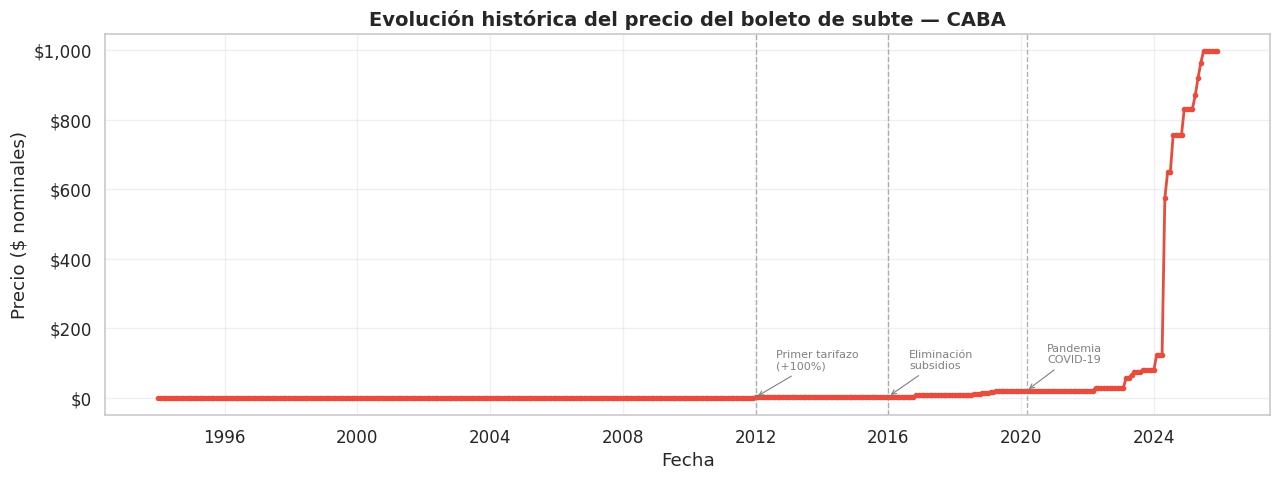

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df_precios['fecha'], df_precios['precio'], color='#E74C3C', linewidth=2, marker='o', markersize=3)

# Marcar hitos clave
hitos = [
    ('2012-01-01', 'Primer tarifazo\n(+100%)'),
    ('2016-01-01', 'Eliminación\nsubsidios'),
    ('2020-03-01', 'Pandemia\nCOVID-19'),
]
for fecha_str, etiqueta in hitos:
    try:
        fecha_dt = pd.to_datetime(fecha_str)
        precio_en_fecha = df_precios.loc[
            df_precios['fecha'] >= fecha_dt, 'precio'
        ].iloc[0] if (df_precios['fecha'] >= fecha_dt).any() else None
        if precio_en_fecha:
            ax.axvline(fecha_dt, color='gray', linestyle='--', alpha=0.6, linewidth=1)
            ax.annotate(etiqueta, xy=(fecha_dt, precio_en_fecha),
                        xytext=(15, 20), textcoords='offset points',
                        fontsize=8, color='gray',
                        arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))
    except:
        pass

ax.set_title('Evolución histórica del precio del boleto de subte — CABA', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio ($ nominales)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('eda_01_precio_historico.png', dpi=150, bbox_inches='tight')
plt.show()

  **Interpretacion.** La tarifa **nominal** muestra una escalada con saltos discretos (cada aumento es un escalón): subsidios que se recortan entre 2012 y 2019, y el salto más violento en **2024**,
  cuando pasa de ~$125 a ~$1.000 en pocos meses. Pero es **precio nominal**: gran parte de esa subida solo refleja la inflación. En términos reales la tarifa **no creció de forma monótona**
  (cayó entre 2014 y 2016 cuando los subsidios la mantenían pisada; ver §1.4). Esta distinción es la que obliga a deflactar antes de estimar cualquier elasticidad (§7.1).

### Contexto: la caída de demanda

El subte alcanzó su **pico histórico en 2018** (~348 millones de viajes anuales). En **2020 la pandemia derrumbó la demanda** a un mínimo sin precedente, muy por encima del impacto de cualquier variación tarifaria. La **serie anual** (cátedra) llega hasta 2020, así que el análisis *anual* por línea (S4.2, S4.9) muestra la caída pero no la recuperación. La **serie mensual**, extendida con datos 2022-2025 (S3.5), sí muestra la **recuperación parcial post-pandemia**: la demanda se recompone pero se estabiliza en un nivel estructuralmente **inferior** al de 2019, consistente con el efecto persistente del teletrabajo.

> **Fuente:** Observatorio del Derecho a la Ciudad (2025). Informe sobre la evolución de pasajeros y la tarifa del subte (2015-2025).


### 4.2 Demanda anual por línea

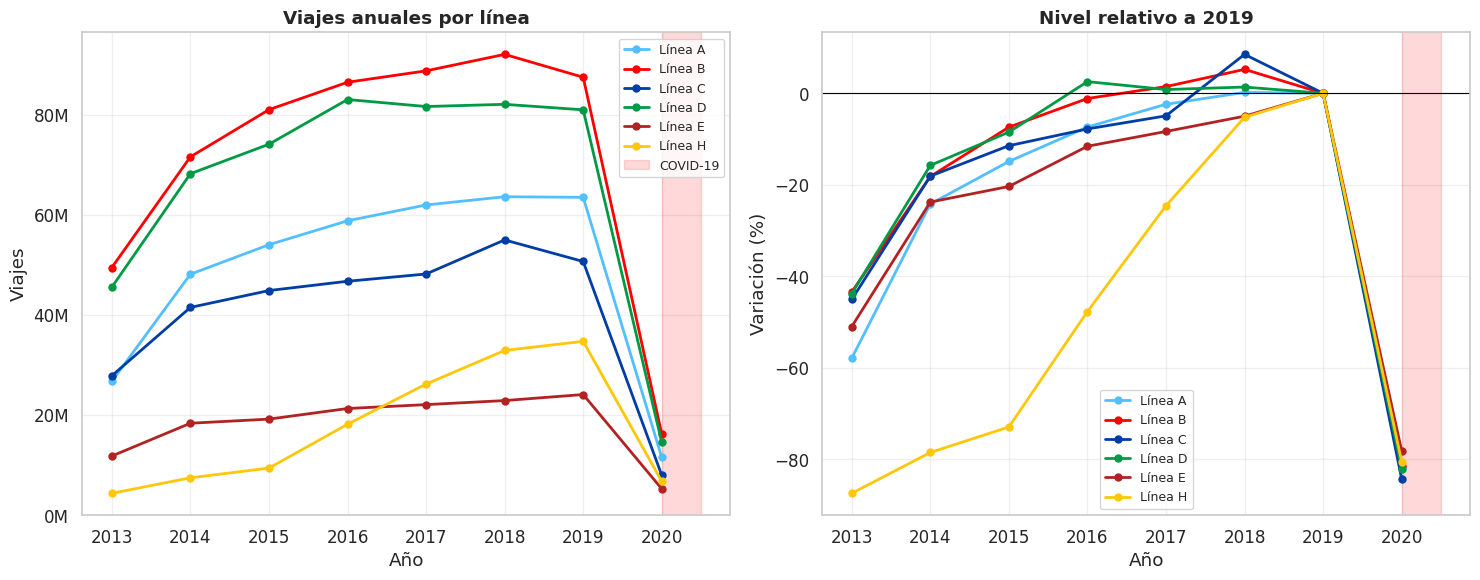

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Izquierda: viajes por línea ---
for linea in sorted(df_anual[col_linea].unique()):
    d = df_anual[df_anual[col_linea] == linea].sort_values('año')
    color = COLORES_LINEAS.get(str(linea).strip(), '#888888')
    axes[0].plot(d['año'], d[col_total], marker='o', label=f'Línea {linea}',
                 color=color, linewidth=2, markersize=5)
axes[0].axvspan(2020, 2020.5, alpha=0.15, color='red', label='COVID-19')
axes[0].set_title('Viajes anuales por línea', fontweight='bold')
axes[0].set_xlabel('Año'); axes[0].set_ylabel('Viajes')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(1))

# --- Derecha: variación % respecto a 2019 (último año pre-pandemia completo) ---
base_2019 = df_anual[df_anual['año'] == 2019].set_index(col_linea)[col_total]
for linea in sorted(df_anual[col_linea].unique()):
    d = df_anual[df_anual[col_linea] == linea].sort_values('año').copy()
    base = base_2019.get(linea)
    if base and base > 0:
        d['variacion'] = (d[col_total] / base - 1) * 100
        color = COLORES_LINEAS.get(str(linea).strip(), '#888888')
        axes[1].plot(d['año'], d['variacion'], marker='o', label=f'Línea {linea}',
                     color=color, linewidth=2, markersize=5)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axvspan(2020, 2020.5, alpha=0.15, color='red')
axes[1].set_title('Nivel relativo a 2019',
                  fontweight='bold')
axes[1].set_xlabel('Año'); axes[1].set_ylabel('Variación (%)')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.tight_layout()
plt.savefig('eda_02_viajes_por_linea.png', dpi=150, bbox_inches='tight')
plt.show()


### Contexto: precio y demanda en el período analizado

Entre 2015 y 2019, la tarifa subió consistentemente mientras la demanda se mantuvo relativamente estable o creció levemente, sugiriendo baja elasticidad en ese tramo. El quiebre estructural del período analizado es **la pandemia de COVID-19 en 2020**, que interrumpió abruptamente cualquier tendencia. El gráfico siguiente permite ver si, antes de ese quiebre, los años de mayores aumentos tarifarios se corresponden con caídas de demanda. Más adelante (S7.3) testeamos formalmente tanto el quiebre de 2020 como el del **tarifazo de mayo-2024**.

> **Fuente:** Observatorio del Derecho a la Ciudad (2025): https://observatoriociudad.org/informe-sobre-la-evoluci%C3%B3n-de-pasajeros-y-la-tarifa-del-subte-de-la-ciudad-de-buenos-aires-en-la-%C3%BAltima-d%C3%A9cada-2015-2025/

### 4.3 Relación viajes totales vs precio (hipótesis H5)

In [ ]:
fig = make_subplots(specs=[[{'secondary_y': True}]])

fig.add_trace(
    go.Bar(x=df_base['año'], y=df_base['total_viajes'],
           name='Total viajes', opacity=0.65, marker_color='steelblue'),
    secondary_y=False
)

fig.add_trace(
    go.Scatter(x=df_base['año'], y=df_base['precio_promedio'],
               name='Precio promedio anual ($)', mode='lines+markers',
               line=dict(color='crimson', width=3), marker=dict(size=8)),
    secondary_y=True
)

fig.add_vline(x=2020, line_dash='dash', line_color='red',
              annotation_text='COVID-19', annotation_position='top')

fig.update_layout(
    title='Relación entre demanda total y precio del boleto (anual)',
    xaxis_title='Año',
    yaxis_title='Total de viajes',
    yaxis2_title='Precio promedio ($)',
    template='plotly_white',
    legend=dict(x=0.01, y=0.99),
    hovermode='x unified'
)

fig.show()
fig.write_html('eda_03_viajes_vs_precio.html')
print('Guardado como eda_03_viajes_vs_precio.html')

✅ Guardado como eda_03_viajes_vs_precio.html


  **Interpretacion.** Entre 2014 y 2019 la tarifa sube de forma sostenida mientras la demanda se mantiene estable o crece levemente (pico en 2018-2019): a simple vista, **el precio no frena la
  demanda** —primer indicio de baja sensibilidad—. El único quiebre real es **2020 (COVID)**, donde la demanda se derrumba con independencia del precio. Atención: este gráfico usa precio
  **nominal**, así que la aparente "suba de precio con demanda firme" mezcla inflación; la relación correcta (precio real) se ve en §4.4.

### 4.4 Análisis de correlación y scatter viajes vs precio

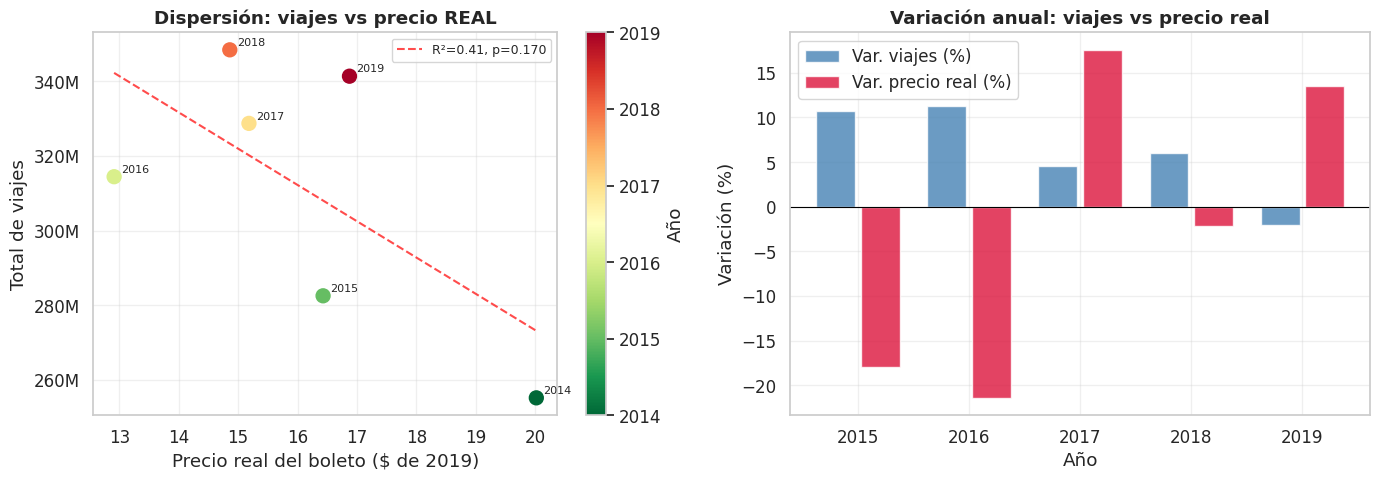

=== Correlaciones viajes vs precio (2014-2019) ===
Pearson  con precio NOMINAL : +0.711
Pearson  con precio REAL    : -0.641
Spearman con precio REAL    : -0.429


In [ ]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Scatter: viajes vs precio REAL (deflactado) ---
scatter = axes[0].scatter(df_base['precio_real'], df_base['total_viajes'],
                          c=df_base['año'], cmap='RdYlGn_r', s=100, zorder=3)
for _, row in df_base.iterrows():
    axes[0].annotate(str(int(row['año'])), (row['precio_real'], row['total_viajes']),
                     textcoords='offset points', xytext=(5, 3), fontsize=8)
mask = df_base[['precio_real', 'total_viajes']].notna().all(axis=1)
if mask.sum() > 2:
    slope, intercept, r_value, p_value, _ = stats.linregress(
        df_base.loc[mask, 'precio_real'], df_base.loc[mask, 'total_viajes'])
    x_line = np.linspace(df_base['precio_real'].min(), df_base['precio_real'].max(), 100)
    axes[0].plot(x_line, slope * x_line + intercept, 'r--', alpha=0.7,
                 label=f'R²={r_value**2:.2f}, p={p_value:.3f}')
    axes[0].legend(fontsize=9)
plt.colorbar(scatter, ax=axes[0], label='Año')
axes[0].set_xlabel('Precio real del boleto ($ de 2019)')
axes[0].set_ylabel('Total de viajes')
axes[0].set_title('Dispersión: viajes vs precio REAL', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
axes[0].grid(alpha=0.3)

# --- Variaciones anuales: precio real vs viajes ---
df_var = df_base.dropna(subset=['var_viajes_pct', 'var_precio_real_pct'])
axes[1].bar(df_var['año'] - 0.2, df_var['var_viajes_pct'], width=0.35,
            label='Var. viajes (%)', color='steelblue', alpha=0.8)
axes[1].bar(df_var['año'] + 0.2, df_var['var_precio_real_pct'], width=0.35,
            label='Var. precio real (%)', color='crimson', alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Variación anual: viajes vs precio real', fontweight='bold')
axes[1].set_xlabel('Año'); axes[1].set_ylabel('Variación (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.tight_layout()
plt.savefig('eda_04_correlacion_precio_viajes.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Correlaciones (período 2014-2019, sin ruido COVID) ---
df_pre = df_base[df_base['año'] < 2020]
print('=== Correlaciones viajes vs precio (2014-2019) ===')
print(f'Pearson  con precio NOMINAL : {df_pre["total_viajes"].corr(df_pre["precio_promedio"]):+.3f}')
print(f'Pearson  con precio REAL    : {df_pre["total_viajes"].corr(df_pre["precio_real"]):+.3f}')
print(f'Spearman con precio REAL    : {df_pre["total_viajes"].corr(df_pre["precio_real"], method="spearman"):+.3f}')


  **Interpretacion:** Con precio **nominal**, viajes y precio correlacionan **+0,71** (positivo): parecería que a mayor precio, mayor demanda. Es **espurio** —ambos suben
  arrastrados por la inflación y la expansión de la red—. Al pasar a precio **real** (deflactado por IPC), la correlación se invierte a **−0,64** (Spearman −0,43): a mayor precio real, menos
  viajes, que es lo que se espera de una curva de demanda. Esto justifica trabajar con precio real en todo el modelado y anticipa una elasticidad negativa e inelástica (§7.1)

### 4.5 Serie temporal mensual (con archivos históricos)

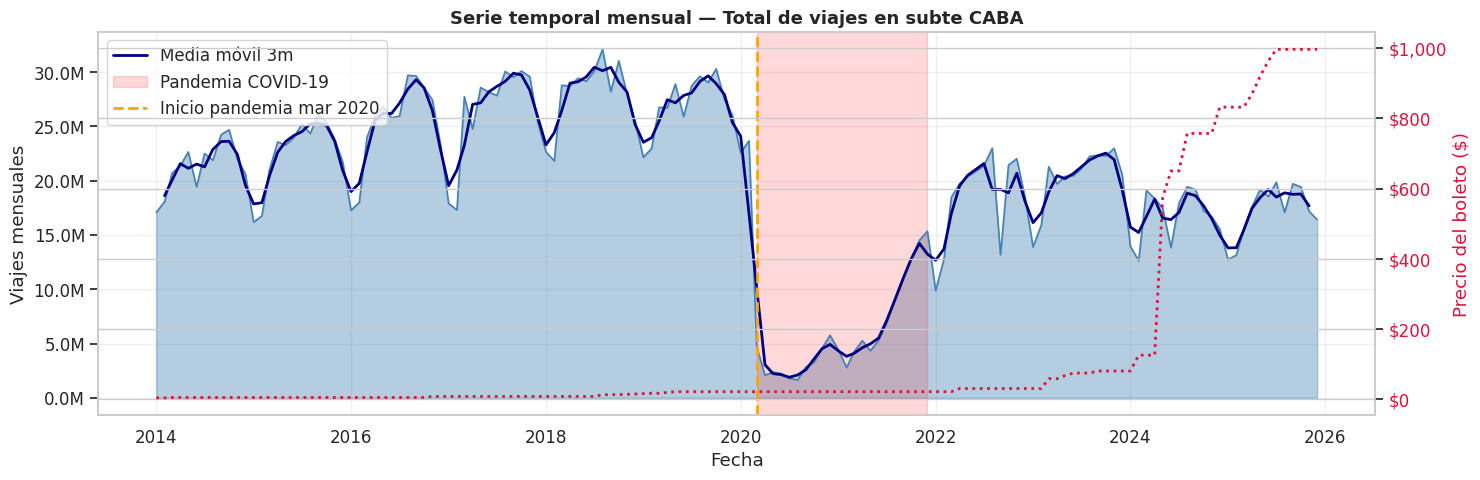

In [ ]:
if df_mensual is not None:
    # Agregar total por mes (todas las líneas)
    df_ts = df_mensual.groupby('fecha')['total_viajes'].sum().reset_index()
    df_ts = df_ts.sort_values('fecha')

    # Merge con precios mensuales
    if 'fecha' in df_precios.columns:
        df_ts = pd.merge(df_ts, df_precios[['fecha', 'precio']], on='fecha', how='left')

    fig, ax1 = plt.subplots(figsize=(15, 5))

    ax1.fill_between(df_ts['fecha'], df_ts['total_viajes'], alpha=0.4, color='steelblue')
    ax1.plot(df_ts['fecha'], df_ts['total_viajes'], color='steelblue', linewidth=1.2)

    # Media móvil 3 meses
    ax1.plot(df_ts['fecha'], df_ts['total_viajes'].rolling(3, center=True).mean(),
             color='navy', linewidth=2, label='Media móvil 3m')

    # Sombrear COVID
    ax1.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-12-01'),
                alpha=0.15, color='red', label='Pandemia COVID-19')

    # Línea de inicio de la pandemia (marzo 2020)
    ax1.axvline(pd.to_datetime('2020-03-01'), color='orange',
            linestyle='--', linewidth=2, label='Inicio pandemia mar 2020')

    ax1.set_title('Serie temporal mensual — Total de viajes en subte CABA', fontweight='bold', fontsize=13)
    ax1.set_ylabel('Viajes mensuales')
    ax1.set_xlabel('Fecha')
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax1.legend(loc='upper left')
    ax1.grid(alpha=0.3)

    # Eje secundario: precio
    if 'precio' in df_ts.columns:
        ax2 = ax1.twinx()
        ax2.plot(df_ts['fecha'], df_ts['precio'], color='crimson',
                 linewidth=2, linestyle=':', label='Precio ($)')
        ax2.set_ylabel('Precio del boleto ($)', color='crimson')
        ax2.tick_params(axis='y', labelcolor='crimson')
        ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    plt.tight_layout()
    plt.savefig('eda_05_serie_temporal_mensual.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Saltear: no hay datos mensuales disponibles (df_mensual es None)')

● **Lectura.** La serie deja ver tres regímenes claros:

  - **2014-2019 (pre-pandemia):** demanda estable con fuerte estacionalidad (caídas en enero y julio por vacaciones), oscilando entre ~17M y ~32M de viajes mensuales, con el pico en
  2018-2019.
  - **2020-2021 (COVID, franja roja):** derrumbe abrupto en marzo-2020 (de ~30M a ~2M) y recuperación lenta y parcial durante 2021. Es el **único quiebre estructural** de toda la serie
  (confirmado por el test de Chow, S7.3).
  - **2022-2025 (post-pandemia):** la demanda se recompone y recupera su estacionalidad, pero se estabiliza en torno a 20-25M, **por debajo del nivel pre-2020** (~30M). Esa brecha
  persistente es consistente con un cambio estructural de hábitos (teletrabajo), no con un efecto del precio.

  **Precio vs. demanda (eje derecho, tarifa nominal).** La tarifa se mantiene casi plana hasta 2022 y luego se dispara, con el salto del tarifazo de 2024 hasta ~$1.000. Pese a ese aumento
  nominal enorme, la serie de viajes **no muestra ninguna caída asociada**: mantiene su nivel y su estacionalidad. Es la evidencia visual del resultado central del trabajo —demanda
  **inelástica** al precio (S7.1) y **sin quiebre** en el tarifazo de mayo-2024 (S7.3)—: el factor que hunde la demanda es la pandemia, no la tarifa.



### 4.6 Distribución por línea — heatmap mensual

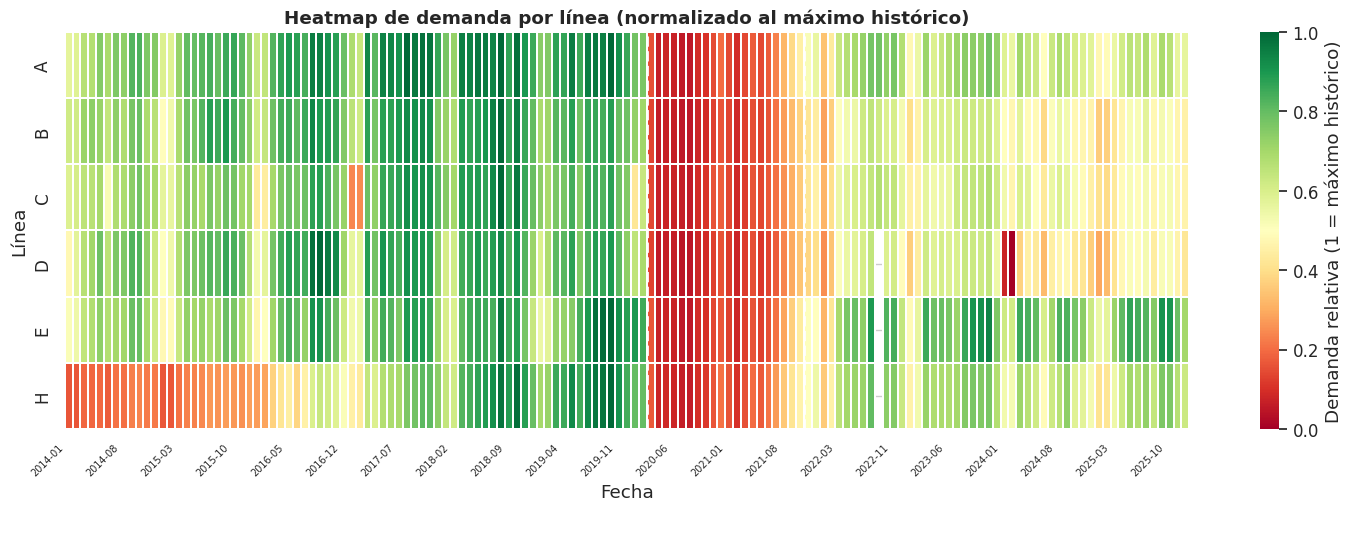

In [ ]:
if df_mensual is not None:
    # Pivot: filas = mes-año, columnas = línea
    df_pivot = df_mensual.pivot_table(
        index='fecha', columns='linea', values='total_viajes', aggfunc='sum'
    )
    df_pivot = df_pivot.sort_index()

    # Normalizar por columna para ver caída relativa
    df_norm = df_pivot.div(df_pivot.max(axis=0), axis=1)

    fig, ax = plt.subplots(figsize=(15, 6))
    sns.heatmap(df_norm.T, ax=ax, cmap='RdYlGn', vmin=0, vmax=1,
                linewidths=0.2, cbar_kws={'label': 'Demanda relativa (1 = máximo histórico)'})

    # Marcar eventos
    fechas_idx = df_norm.index.tolist()
    for evento, fecha_str in [('COVID', '2020-03-01'), ('Reapertura', '2021-11-01')]:
        try:
            fecha_dt = pd.to_datetime(fecha_str)
            pos = next((i for i, f in enumerate(fechas_idx) if f >= fecha_dt), None)
            if pos:
                ax.axvline(pos, color='white', linewidth=2, linestyle='--')
                ax.text(pos, -0.3, evento, color='white', fontsize=8,
                        ha='center', transform=ax.get_xaxis_transform())
        except:
            pass

    ax.set_title('Heatmap de demanda por línea (normalizado al máximo histórico)', fontweight='bold')
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Línea')

    # Reducir etiquetas del eje X
    step = max(1, len(fechas_idx) // 20)
    ax.set_xticks(range(0, len(fechas_idx), step))
    ax.set_xticklabels(
        [str(fechas_idx[i])[:7] for i in range(0, len(fechas_idx), step)],
        rotation=45, ha='right', fontsize=7
    )

    plt.tight_layout()
    plt.savefig('eda_06_heatmap_lineas.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Saltear: no hay datos mensuales disponibles')

  **Interpretacion.** Cada fila es una línea y el color es su demanda relativa a su propio máximo (verde = alto, rojo = bajo). Tres lecturas: (1) **la caída de 2020 es pareja en todas las líneas**
  —el shock COVID fue transversal, no afectó a una línea en particular—; (2) la **Línea H aparece roja al inicio (2014-2016)** no por falta de demanda estructural sino porque todavía estaba
  en **expansión de estaciones** (por eso después se "enverdece"); (3) tras 2022 las líneas se recuperan pero **no vuelven al verde pleno**, lo que confirma que la demanda se estabilizó por
  debajo del nivel pre-pandemia.

### 4.7 Análisis horario con muestra de molinetes

> Usa una muestra (primeras 300k filas) de los molinetes detallados de 2019 y 2021, cargada automáticamente desde los `historico_*.csv` de la cátedra. Requiere `PROCESAR_DATOS=True` (descarga los archivos crudos).

In [ ]:
def cargar_muestra_molinetes(ruta, n_rows=300_000, label=''):
    """Carga una muestra de molinetes detectando separador, encoding y nombres
    de columna (varían según el año). Usa pax_TOTAL si está disponible."""
    # 1) Detectar separador leyendo la primera línea
    with open(ruta, encoding='utf-8', errors='replace') as fh:
        head = fh.readline()
    sep = ';' if head.count(';') > head.count(',') else ','

    for enc in ['utf-8', 'latin-1', 'iso-8859-1']:
        try:
            df = pd.read_csv(ruta, sep=sep, nrows=n_rows, encoding=enc, low_memory=False)
            if df.shape[1] == 1:           # separador equivocado → reintentar
                continue
            df.columns = df.columns.str.lower().str.strip()

            for col in ['fecha', 'desde', 'fecha_desde']:
                if col in df.columns:
                    df['fecha_hora'] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)
                    break
            # Preferir el TOTAL de pasajeros sobre solo los pagos
            for col in ['pax_total', 'total', 'pax_pagos', 'cantidad']:
                if col in df.columns:
                    df['pax'] = pd.to_numeric(df[col], errors='coerce')
                    break
            for col in ['linea', 'línea', 'line']:
                if col in df.columns:
                    df['linea'] = df[col].astype(str).str.strip().str.upper()
                    break
            # Hora desde la columna 'desde' (HH:MM:SS); fallback a fecha_hora
            if 'desde' in df.columns:
                df['hora'] = pd.to_datetime(df['desde'], format='%H:%M:%S',
                                            errors='coerce').dt.hour
            elif 'fecha_hora' in df.columns:
                df['hora'] = df['fecha_hora'].dt.hour
            if 'fecha_hora' in df.columns:
                df['dia_semana'] = df['fecha_hora'].dt.dayofweek
                df['nombre_dia'] = df['fecha_hora'].dt.day_name()

            df['periodo'] = label
            print(f'{label}: {df.shape[0]:,} filas (sep="{sep}", enc={enc}, {df.shape[1]} cols)')
            return df
        except Exception:
            continue
    print(f'No se pudo cargar {ruta}')
    return None


df_mol_2019 = df_mol_2021 = None
if historicos:
    a19 = next((path + f for f in historicos if '2019' in f), None)
    a21 = next((path + f for f in historicos if '2021' in f), None)
    if a19:
        df_mol_2019 = cargar_muestra_molinetes(a19, label='2019')
    if a21:
        df_mol_2021 = cargar_muestra_molinetes(a21, label='2021')
else:
    print('Sin archivos históricos: se omite la muestra detallada de molinetes.')

print(f'\nMuestra 2019: {"✅" if df_mol_2019 is not None else "—"} | '
      f'Muestra 2021: {"✅" if df_mol_2021 is not None else "—"}')


✅ 2019: 300,000 filas (sep=",", enc=utf-8, 16 cols)
✅ 2021: 300,000 filas (sep=";", enc=utf-8, 16 cols)

Muestra 2019: ✅ | Muestra 2021: ✅


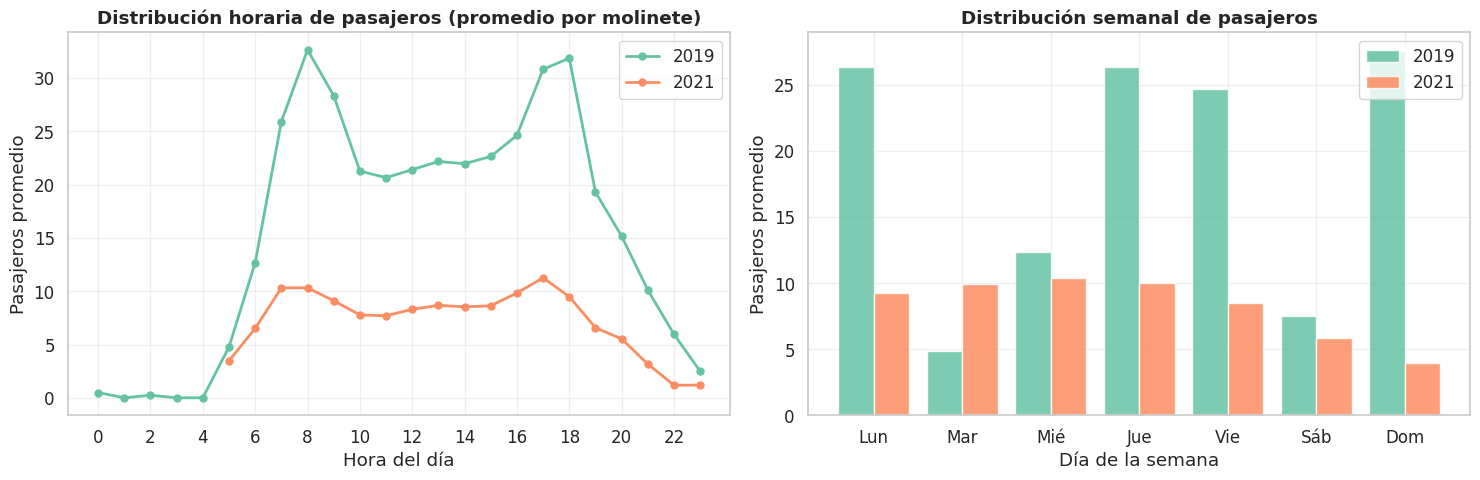

Nota: la muestra son las primeras 300k filas de cada año (no aleatoria);
refleja la FORMA de la curva, no volúmenes absolutos comparables entre años.


In [ ]:
# ─── Curva horaria y semanal: comparación 2019 (pre-pandemia) vs 2021 (post) ──
datasets_disponibles = [(df, label) for df, label in
    [(df_mol_2019, '2019'), (df_mol_2021, '2021')]
    if df is not None and 'hora' in df.columns and 'pax' in df.columns]

if datasets_disponibles:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    for df, label in datasets_disponibles:
        horario = df.groupby('hora')['pax'].mean()
        axes[0].plot(horario.index, horario.values, marker='o',
                     label=label, linewidth=2, markersize=5)
    axes[0].set_title('Distribución horaria de pasajeros (promedio por molinete)',
                      fontweight='bold')
    axes[0].set_xlabel('Hora del día'); axes[0].set_ylabel('Pasajeros promedio')
    axes[0].set_xticks(range(0, 24, 2)); axes[0].legend(); axes[0].grid(alpha=0.3)

    dias_es = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
    for i, (df, label) in enumerate(datasets_disponibles):
        semanal = df.groupby('dia_semana')['pax'].mean().reindex(range(7))
        offset = (i - (len(datasets_disponibles) - 1) / 2) * 0.4
        axes[1].bar([d + offset for d in range(7)], semanal.values,
                    width=0.4, label=label, alpha=0.85)
    axes[1].set_title('Distribución semanal de pasajeros', fontweight='bold')
    axes[1].set_xlabel('Día de la semana'); axes[1].set_ylabel('Pasajeros promedio')
    axes[1].set_xticks(range(7)); axes[1].set_xticklabels(dias_es)
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('eda_07_patron_horario_semanal.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Nota: la muestra son las primeras 300k filas de cada año (no aleatoria);')
    print('refleja la FORMA de la curva, no volúmenes absolutos comparables entre años.')
else:
    print(' Sin muestras detalladas disponibles (no se cargaron los históricos).')


  **Interpretacion:** La curva horaria tiene el **doble pico** típico de un día hábil (mañana ~8 h y tarde ~17-18 h). Comparando **2019 vs 2021**, la curva de 2021 es más baja y con el **pico de la
  mañana más achatado**, compatible con el efecto del teletrabajo (menos viajes de ingreso temprano a oficinas). En la distribución semanal, los días hábiles concentran la demanda y los fines
  de semana caen. El top de estaciones lo dominan **nodos de trasbordo y cabeceras conectadas al ferrocarril** (Constitución, Retiro, Federico Lacroze), lo que explica por qué las líneas que
  tocan esos nodos sostienen mejor su demanda.

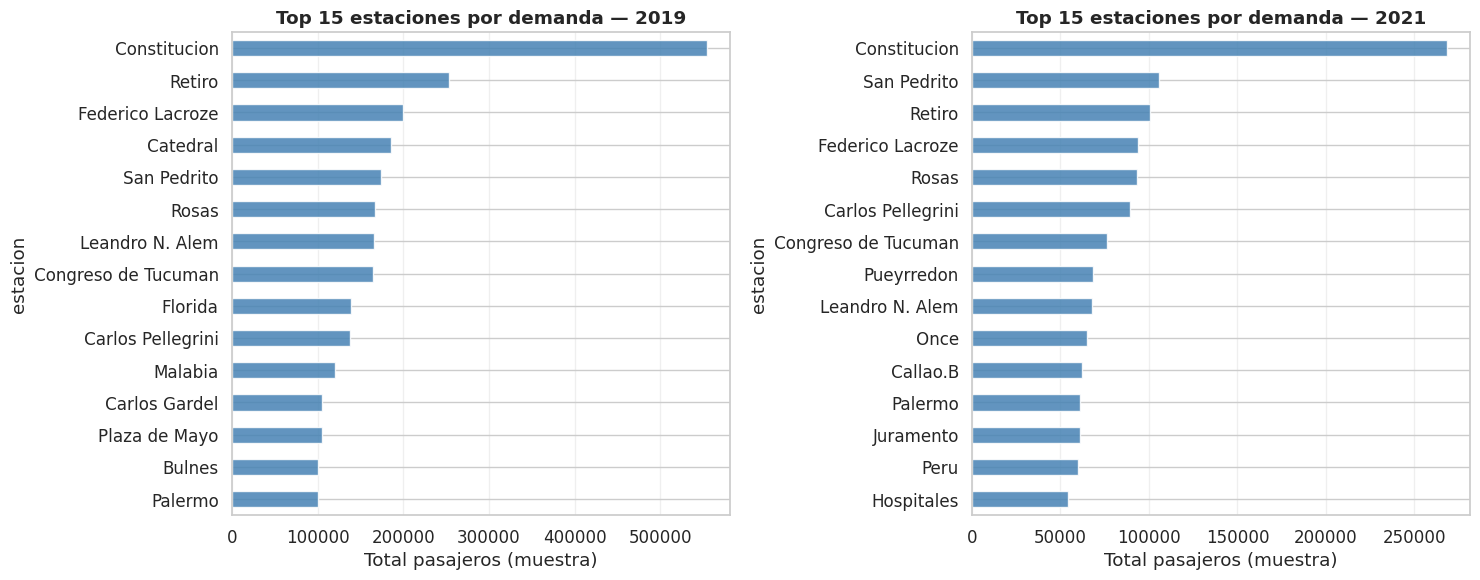

In [ ]:
if datasets_disponibles and all('estacion' in df.columns or 'station' in df.columns
                                for df, _ in datasets_disponibles):
    fig, axes = plt.subplots(1, len(datasets_disponibles), figsize=(15, 6))
    if len(datasets_disponibles) == 1:
        axes = [axes]

    for ax, (df, label) in zip(axes, datasets_disponibles):
        col_est = 'estacion' if 'estacion' in df.columns else 'station'
        top = df.groupby(col_est)['pax'].sum().nlargest(15).sort_values()
        top.plot(kind='barh', ax=ax, color='steelblue', alpha=0.85)
        ax.set_title(f'Top 15 estaciones por demanda — {label}', fontweight='bold')
        ax.set_xlabel('Total pasajeros (muestra)')
        ax.grid(alpha=0.3, axis='x')

    plt.tight_layout()
    plt.savefig('eda_08_top_estaciones.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Sin columna de estación disponible en los datos actuales.')

### Contexto: evidencia previa de elasticidad diferenciada por línea

La tesis de la UTDT (2020) estimó una elasticidad-precio **inelástica** (entre −0,1 y −0,2): una suba del 10% en la tarifa reduce la demanda entre 1% y 2%. Sin embargo, encontró **diferencias significativas por línea**: la Línea D es la más sensible al precio, las Líneas A y E las menos elásticas. El CEM (2025) confirma que en el período reciente las **líneas B y D** registran la mayor pérdida de pasajeros.

El coeficiente de `log_precio` en la regresión siguiente es directamente interpretable como la **elasticidad-precio** de la demanda.

> **Fuentes:**
> - Observatorio del Derecho a la Ciudad (21/06/2025): https://observatoriociudad.org/informe-sobre-la-evoluci%C3%B3n-de-pasajeros-y-la-tarifa-del-subte-de-la-ciudad-de-buenos-aires-en-la-%C3%BAltima-d%C3%A9cada-2015-2025/
> - IIEP-UBA/CONICET en Infobae (19/06/2025): https://www.infobae.com/economia/2025/06/19/se-desplomo-40-el-uso-del-subte-desde-la-pandemia-el-impacto-del-teletrabajo-y-la-suba-del-boleto/

### 4.8 Elasticidad tarifaria — estimación anual exploratoria (precio real)

Estimación **exploratoria** (anual, 2014-2019, n=6) en log-log con **precio real**. El coeficiente de `log(precio_real)` aproxima la elasticidad-precio. Con tan pocos puntos la inferencia es débil (la estimación robusta es el panel mensual de S7.1); el objetivo acá es solo mostrar el **signo y orden de magnitud** y contrastar nominal vs. real.


In [ ]:
import statsmodels.api as sm

df_e = df_base.dropna(subset=['total_viajes', 'precio_real', 'precio_promedio']).copy()
df_e['log_viajes'] = np.log(df_e['total_viajes'])
df_e['t'] = df_e['año'] - df_e['año'].min()

print('=== Elasticidad anual exploratoria (2014-2019, n={}) ==='.format(len(df_e)))
for etiqueta, pcol in [('NOMINAL', 'precio_promedio'), ('REAL (deflactado)', 'precio_real')]:
    df_e['log_p'] = np.log(df_e[pcol])
    X = sm.add_constant(df_e[['log_p', 't']])   # precio + tendencia temporal
    m = sm.OLS(df_e['log_viajes'], X).fit()
    e, p = m.params['log_p'], m.pvalues['log_p']
    print(f'  {etiqueta:18s}: elasticidad = {e:+.3f}  (p={p:.3f}, R²adj={m.rsquared_adj:.2f})')

print('\nLectura: con precio NOMINAL el coeficiente sale con signo engañoso por la')
print('tendencia inflacionaria común. Con precio REAL + tendencia el signo es NEGATIVO')
print('y del orden de la literatura (UTDT: -0,1 a -0,2). Es exploratorio (n pequeño);')
print('la estimación con potencia estadística es el panel mensual de S7.1.')


=== Elasticidad anual exploratoria (2014-2019, n=6) ===
  NOMINAL           : elasticidad = -0.247  (p=0.005, R²adj=0.99)
  REAL (deflactado) : elasticidad = -0.272  (p=0.031, R²adj=0.97)

Lectura: con precio NOMINAL el coeficiente sale con signo engañoso por la
tendencia inflacionaria común. Con precio REAL + tendencia el signo es NEGATIVO
y del orden de la literatura (UTDT: -0,1 a -0,2). Es exploratorio (n pequeño);
la estimación con potencia estadística es el panel mensual de §7.1.


### 4.9 Profundidad de la caída de 2020 por línea

Comparamos los viajes de **2020 (año del shock COVID)** contra **2019** por línea. Como los datos anuales terminan en 2020, esto mide la **profundidad de la caída pandémica**, no una recuperación posterior. Todas las líneas caen entre −78 % y −84 %.


In [ ]:
# Profundidad de la caída 2020 vs 2019 por línea (los datos anuales llegan a 2020)
anio_base, anio_shock = 2019, int(df_anual['año'].max())   # 2020 en estos datos
lineas = sorted(df_anual[col_linea].unique())

filas = []
for linea in lineas:
    d = df_anual[df_anual[col_linea] == linea]
    v0 = d[d['año'] == anio_base][col_total].values
    v1 = d[d['año'] == anio_shock][col_total].values
    if len(v0) and len(v1):
        filas.append({'Línea': str(linea).strip(),
                      f'Viajes {anio_base}': v0[0],
                      f'Viajes {anio_shock}': v1[0],
                      f'Var % {anio_shock} vs {anio_base}': round((v1[0]/v0[0]-1)*100, 1)})

col_var = f'Var % {anio_shock} vs {anio_base}'
df_caida = pd.DataFrame(filas).sort_values(col_var)
print(f'Caída {anio_shock} vs {anio_base} por línea (más negativo = mayor caída):')
print(df_caida.to_string(index=False))


Caída 2020 vs 2019 por línea (más negativo = mayor caída):
Línea  Viajes 2019  Viajes 2020  Var % 2020 vs 2019
    C     50661307      7989026               -84.2
    D     80941537     14540456               -82.0
    A     63469412     11547922               -81.8
    B     87449121     16221726               -81.5
    H     34721804      6766380               -80.5
    E     24097320      5270933               -78.1


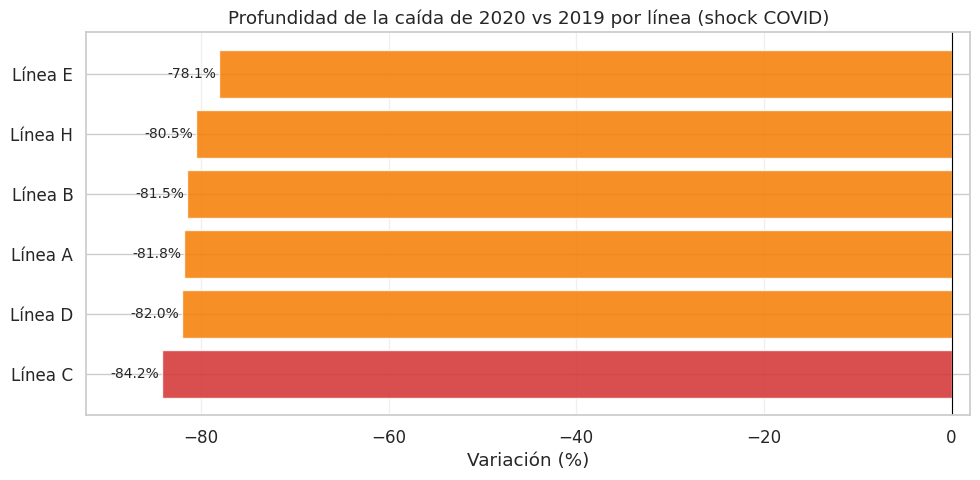

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
colores = ['#D32F2F' if v < -82 else '#F57C00' for v in df_caida[col_var]]
bars = ax.barh(df_caida['Línea'].apply(lambda x: f'Línea {x}'),
               df_caida[col_var], color=colores, alpha=0.85)
for bar, val in zip(bars, df_caida[col_var]):
    ax.text(val - 0.3, bar.get_y() + bar.get_height()/2, f'{val:+.1f}%',
            va='center', ha='right', fontsize=10)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Profundidad de la caída de {anio_shock} vs {anio_base} por línea (shock COVID)')
ax.set_xlabel('Variación (%)'); ax.grid(alpha=0.3, axis='x')
ax.set_xlim(df_caida[col_var].min() - 8, 2)
plt.tight_layout()
plt.savefig('eda_09_caida_2020_por_linea.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Resumen del EDA — Hallazgos principales

**1. Tendencia macro**
- Pico histórico en **2018** (~348 M de viajes anuales).
- **2016 NO fue una caída:** los viajes crecieron (+11 % interanual). El crecimiento se sostuvo hasta 2018.
- **2020:** derrumbe pandémico (caída de **−78 % a −84 % por línea** vs 2019), sin precedente. La serie mensual extendida (2022-2025) muestra una **recuperación parcial**, que se estabiliza por debajo del nivel pre-pandemia.

**2. Precio: nominal vs. real**
- En términos **nominales** la tarifa subió ~1900 % (2006-2019), pero eso refleja sobre todo la inflación.
- En términos **reales** (deflactados por IPCBA) la tarifa **no creció de forma monótona**: cayó entre 2014 y 2016 (subsidios + inflación) y se recuperó después. Este es el insumo correcto para la elasticidad (S7.1).

**3. Relación precio-demanda**
- La correlación con el precio **nominal** es positiva, pero **espuria** (ambos crecen con la inflación).
- Estimada correctamente (precio real, panel con controles), la elasticidad es **negativa e inelástica**, consistente con la literatura (S7.1).

**4. Heterogeneidad por línea**
- La caída de 2020 fue relativamente pareja (Línea C la más afectada en los datos anuales).
- La línea **H** se comporta distinto por **expansión de estaciones** en el período, no por sensibilidad al precio — se trata aparte en S7.1.

**5. Patrones temporales**
- Doble pico (mañana y tarde) en días hábiles; el clustering de S7.4 distingue perfiles tipo "oficina" (pico AM) de "mixto/tarde".

> Estos hallazgos guían el modelado: (a) usar **precio real**, (b) controlar **tendencia** y **estacionalidad**, (c) modelar **heterogeneidad por línea**, (d) testear el **quiebre COVID**.


---
## Del EDA al modelado

El EDA dejó tres intuiciones que las etapas siguientes formalizan:

1. La relación precio–demanda pre-2020 es débil y queda dominada por el shock COVID → la **Etapa 2** prepara las variables (régimen tarifario, franjas, controles temporales) y la **Etapa 3** estima la elasticidad controlando por esos factores.
2. La caída por línea no es uniforme → se modela una **elasticidad diferencial por línea**.
3. Hay quiebres candidatos (pandemia 2020 y tarifazo 2024) → se testean formalmente con **Chow**.



## 6. Etapa 2 — Control de calidad y variables derivadas

Mientras la S3 *preparó* los datasets (agregación, normalización de nombres, deflactor), esta etapa hace el **control de calidad** (nulos, duplicados, outliers) y la **ingeniería de variables** que consumen los modelos de la Etapa 3. Se trabaja sobre los datasets ya cargados, incluida la muestra detallada de molinetes del EDA (S4.7). Criterio rector: **no destruir señal real** (la caída COVID son valores extremos *legítimos*, no errores).


### 6.1 Valores nulos y duplicados

Revisamos calidad sobre los datasets que alimentan el modelado (`df_mensual` y, si está cargada, la muestra de molinetes `df_mol_2019`).
- **Duplicados:** se eliminan (filas idénticas = doble conteo).
- **Nulos en `pax`:** se imputan con la **mediana por hora** (robusta a la fuerte asimetría horaria), en lugar de eliminar, para no perder cobertura.


In [ ]:
print('=== Calidad de datos ===')
_tiene_mol = 'df_mol_2019' in dir() and df_mol_2019 is not None
_targets = [('df_mensual', df_mensual)] + ([('df_mol_2019', df_mol_2019)] if _tiene_mol else [])
for nombre, df in _targets:
    print(f'{nombre}: {len(df):,} filas | nulos={df.isnull().sum().sum()} | duplicados={df.duplicated().sum()}')

if _tiene_mol:
    df_mol_2019 = df_mol_2019.drop_duplicates().reset_index(drop=True)
    if 'pax' in df_mol_2019.columns and 'hora' in df_mol_2019.columns:
        df_mol_2019['pax'] = df_mol_2019['pax'].fillna(
            df_mol_2019.groupby('hora')['pax'].transform('median'))
    print(f'→ df_mol_2019 tras limpiar: {len(df_mol_2019):,} filas | nulos={df_mol_2019.isnull().sum().sum()}')


=== Calidad de datos ===
df_mensual: 855 filas | nulos=0 | duplicados=0
df_mol_2019: 300,000 filas | nulos=0 | duplicados=0
→ df_mol_2019 tras limpiar: 300,000 filas | nulos=0


### 6.2 Detección y manejo de outliers

Aplicamos el criterio del **rango intercuartílico (IQR)**, distinguiendo dos casos con tratamiento opuesto:
- **Molinetes (`pax`):** valores extremos sueltos suelen ser **errores de carga**. Se *winsorizan* al límite IQR (3×) — se acota el valor, **sin eliminar la observación**.
- **Serie mensual:** los meses de la pandemia caen fuera del rango IQR pero son **datos reales y centrales para la hipótesis**. Se **conservan**: eliminarlos sería borrar el fenómeno que queremos estudiar.


In [ ]:
print('=== Outliers ===')
if _tiene_mol and 'pax' in df_mol_2019.columns:
    q1, q3 = df_mol_2019['pax'].quantile([0.25, 0.75])
    lim_sup = q3 + 3 * (q3 - q1)
    n_out = int((df_mol_2019['pax'] > lim_sup).sum())
    print(f'molinetes: límite IQR(3x)={lim_sup:.0f} | outliers={n_out} ({n_out/len(df_mol_2019)*100:.2f}%)')
    df_mol_2019['pax'] = df_mol_2019['pax'].clip(upper=lim_sup)
    print('→ winsorizado (se preserva el nº de observaciones)')

# Serie mensual: los meses COVID son outliers LEGÍTIMOS → se conservan
serie_q = df_mensual.groupby('fecha')['total_viajes'].sum()
q1m, q3m = serie_q.quantile([0.25, 0.75]); iqrm = q3m - q1m
fuera = serie_q[(serie_q < q1m - 1.5*iqrm) | (serie_q > q3m + 1.5*iqrm)]
print(f'serie mensual: {len(fuera)} meses fuera de rango IQR → se CONSERVAN (caída COVID real, no error)')


=== Outliers ===
molinetes: límite IQR(3x)=105 | outliers=4222 (1.41%)
→ winsorizado (se preserva el nº de observaciones)
serie mensual: 7 meses fuera de rango IQR → se CONSERVAN (caída COVID real, no error)


### 6.3 Variables derivadas

Generamos las variables que **efectivamente consumen** los modelos de la Etapa 3:
- Sobre molinetes: **franja horaria** y **tipo de día** → insumo del clustering (S7.4) y del análisis de picos.
- Sobre la serie mensual: **precio real** (deflactado), variables de **estacionalidad** (`mes`) y **dummy de pandemia** → insumos de la regresión (S7.1) y el SARIMAX (S7.2).

> La `dummy post_tarifazo` se define **parametrizable**: con datos hasta 2021 no marca ningún tarifazo central de H5 (que es de mayo-2024), por lo que **no se usa en los modelos** de esta versión; queda lista para reapuntarse a `2024-05-01` cuando se incorporen datos 2022-2025.


In [ ]:
# --- Variables sobre molinetes (insumo del clustering y picos) ---
for _df, _lbl in [(df_mol_2019, '2019'), (df_mol_2021, '2021')]:
    if _df is not None and 'hora' in _df.columns:
        _df['franja'] = pd.cut(_df['hora'], bins=[-1, 5, 9, 16, 20, 23],
                               labels=['Madrugada', 'Pico AM', 'Valle', 'Pico PM', 'Noche'])
        if 'dia_semana' in _df.columns:
            _df['tipo_dia'] = np.where(_df['dia_semana'] < 5, 'Hábil', 'Finde')
if df_mol_2019 is not None and 'franja' in df_mol_2019.columns:
    print('franja (2019):', df_mol_2019['franja'].value_counts().to_dict())

# --- Variables sobre la serie mensual (insumo de S7.1 y S7.2) ---
df_features = df_mensual.groupby('fecha')['total_viajes'].sum().reset_index()
df_features['mes_num']   = df_features['fecha'].dt.month
df_features['trimestre'] = df_features['fecha'].dt.quarter
df_features['pandemia']  = (df_features['fecha'] >= '2020-03-01').astype(int)
# Precio nominal y precio REAL (deflactado por IPCBA)
df_features = df_features.merge(df_precios[['fecha', 'precio']], on='fecha', how='left')
df_features = df_features.merge(df_ipc.rename(columns={'ipc': 'ipc_m'}), on='fecha', how='left')
_ipc_2019_12 = df_ipc.loc[df_ipc['fecha'] == '2019-12-01', 'ipc']
_base = _ipc_2019_12.values[0] if len(_ipc_2019_12) else df_ipc['ipc'].iloc[-1]
df_features['precio_real'] = df_features['precio'] * _base / df_features['ipc_m']
# Dummy parametrizable (no usada en modelos con datos <=2021; lista para 2024-05)
FECHA_TARIFAZO = '2024-05-01'
df_features['post_tarifazo'] = (df_features['fecha'] >= FECHA_TARIFAZO).astype(int)

print('\nVariables derivadas de la serie mensual:',
      [c for c in df_features.columns if c != 'total_viajes'])
display(df_features.head())


franja (2019): {'Valle': 127416, 'Pico PM': 72109, 'Pico AM': 61961, 'Noche': 31806, 'Madrugada': 6708}

Variables derivadas de la serie mensual: ['fecha', 'mes_num', 'trimestre', 'pandemia', 'precio', 'ipc_m', 'precio_real', 'post_tarifazo']


,fecha,total_viajes,mes_num,trimestre,pandemia,precio,ipc_m,precio_real,post_tarifazo
0,2014-01-01,17080258.0,1,1,0,3.5,9.366105,22.798462,0
1,2014-02-01,18068193.0,2,1,0,3.5,9.775909,21.842757,0
2,2014-03-01,20689889.0,3,1,0,4.5,10.132685,27.094710,0
3,2014-04-01,21366758.0,4,2,0,4.5,10.449115,26.274202,0
4,2014-05-01,22648413.0,5,2,0,4.5,10.709637,25.635057,0


## 7. Etapa 3 — Modelado

Conectamos las técnicas del marco teórico con H5. Modelos: **regresión lineal múltiple** (elasticidad-precio real, global y por línea, con IC 95 %), **SARIMAX** (serie mensual con tarifa exógena) y **clustering** (perfiles horarios de estaciones). Métricas: elasticidad con IC 95 %, R² ajustado, MAE y RMSE según corresponda.

> **Sobre clasificación.** El objetivo específico 3 menciona modelos de regresión, clasificación y clustering. En este problema la variable de interés (demanda de pasajeros) es **continua**, por lo que el abordaje natural es **regresión + series temporales**, y la estructura latente se explora con **clustering**. No se incluye un modelo de **clasificación supervisada** porque no hay una etiqueta categórica intrínseca al fenómeno (forzar una —p. ej. "mes de demanda alta/baja"— sería artificial y no aportaría a H5). Se deja explícito como decisión metodológica, no como omisión.
>
> **Cobertura (esta entrega):** con la extensión 2022-2025 activa (S3.5), la serie cubre **2014-2025**, lo que permite **testear el tarifazo de mayo-2024 directamente** (test de Chow S7.3 y SARIMAX S7.2). El panel de elasticidad (S7.1) se mantiene en **2014-2019**, donde la tarifa real tiene variación limpia y sin el ruido del shock COVID.


### 7.1 Regresión lineal múltiple — elasticidad-precio (real) por línea

**Especificación.** Panel mensual línea × mes (2014-2019), log-log con **precio real**:

`log(viajes) = β·log(precio_real) + tendencia + EF línea + EF mes + ε`

β es la **elasticidad-precio**. Decisiones:
- **Precio real, no nominal.** Deflactamos por IPCBA. Con tarifa nominal **y sin controlar la tendencia**, la relación precio–demanda aparece con **signo positivo espurio** (ambos crecen con la inflación), como se ve en la correlación cruda del EDA (S4.4, Pearson +0,71). Al **deflactar y/o agregar la tendencia temporal**, el signo se corrige; el control con precio nominal (abajo) queda cercano al de precio real, lo que muestra que removida la tendencia ambos convergen. El **precio real** es la variable conceptualmente correcta y la especificación principal.
- **Tendencia temporal (`t`).** Absorbe el crecimiento secular de la demanda (expansión de red), que de otro modo se confunde con el precio.
- **EF de línea y de mes.** Nivel estructural de cada línea y estacionalidad.
- **Panel mensual (n≈432), no anual (n=6).** Potencia estadística e IC 95 % informativos.
- **Modelo diferencial por línea** (interacciones línea × log(precio_real)) para H5.

> **Identificación.** La tarifa es **única para todas las líneas**: no hay variación de precio *entre* líneas en un mismo mes. La elasticidad *diferencial* se identifica por las distintas **trayectorias de demanda** de cada línea frente al precio común; son **asociaciones**, no efectos causales aislados. La **Línea H** tuvo **expansión de estaciones** en el período, lo que infla su coeficiente por una razón ajena al precio (se señala explícitamente).


In [ ]:
import statsmodels.api as sm

# Panel mensual línea × mes (2014-2019) con precio REAL (deflactado por IPCBA)
pm = df_precios[['fecha', 'precio']].dropna()
panel = df_mensual.merge(pm, on='fecha', how='inner')
panel = panel.merge(df_ipc, on='fecha', how='left')
panel = panel[(panel['fecha'] >= '2014-01-01') & (panel['fecha'] <= '2019-12-01')].copy()
_base = df_ipc.loc[df_ipc['fecha'] == '2019-12-01', 'ipc'].values[0]
panel['precio_real'] = panel['precio'] * _base / panel['ipc']

panel['log_viajes'] = np.log(panel['total_viajes'])
panel['log_precio'] = np.log(panel['precio_real'])
panel['mes_num'] = panel['fecha'].dt.month
panel['t'] = (panel['fecha'].dt.year - 2014) * 12 + panel['fecha'].dt.month - 1

X = pd.get_dummies(panel[['log_precio', 't', 'linea', 'mes_num']],
                   columns=['linea', 'mes_num'], drop_first=True, dtype=float)
X = sm.add_constant(X)
m_global = sm.OLS(panel['log_viajes'], X).fit()
e = m_global.params['log_precio']; ic = m_global.conf_int().loc['log_precio']

print('=== Elasticidad-precio global (precio REAL + tendencia + EF línea/mes) ===')
print(f'n = {int(m_global.nobs)}   | período 2014-2019')
print(f'Elasticidad: {e:+.3f}   IC95% [{ic[0]:+.3f}, {ic[1]:+.3f}]   '
      f'p = {m_global.pvalues["log_precio"]:.4g}')
print(f'R² ajustado: {m_global.rsquared_adj:.3f}')
# Interpretación atenta al SIGNO (no solo a |e|)
if e < 0:
    tipo = 'INELÁSTICA' if abs(e) < 1 else 'ELÁSTICA'
    print(f'→ Elasticidad NEGATIVA y {tipo} (signo esperado para una curva de demanda).')
else:
    print('→ Coeficiente POSITIVO: no interpretable como elasticidad-precio.')
    print('   Revisar controles (tendencia/inflación). Comparar con la versión nominal.')

# Comparación con precio NOMINAL (para evidenciar el sesgo)
Xn = X.copy(); Xn['log_precio'] = np.log(panel['precio'])
e_nom = sm.OLS(panel['log_viajes'], Xn).fit().params['log_precio']
print(f'\n[control] Misma especificación con precio NOMINAL: elasticidad = {e_nom:+.3f}')
print('La diferencia de signo/magnitud entre real y nominal es el sesgo inflacionario.')


=== Elasticidad-precio global (precio REAL + tendencia + EF línea/mes) ===
n = 432   | período 2014-2019
Elasticidad: -0.219   IC95% [-0.325, -0.113]   p = 5.955e-05
R² ajustado: 0.894
→ Elasticidad NEGATIVA y INELÁSTICA (signo esperado para una curva de demanda).

[control] Misma especificación con precio NOMINAL: elasticidad = -0.198
La diferencia de signo/magnitud entre real y nominal es el sesgo inflacionario.


=== Elasticidad-precio por línea (referencia = A) ===
       elasticidad  IC95_inf  IC95_sup
linea                                 
H           -0.655    -0.909    -0.401
D           -0.161    -0.415     0.093
B           -0.148    -0.402     0.106
C           -0.142    -0.396     0.112
A           -0.137    -0.391     0.117
E           -0.071    -0.326     0.183

R² ajustado: 0.897
Nota: la Línea H tuvo expansión de estaciones en 2014-2019; su coeficiente NO
debe leerse como sensibilidad al precio. La lectura de H5 se discute en §7.5.


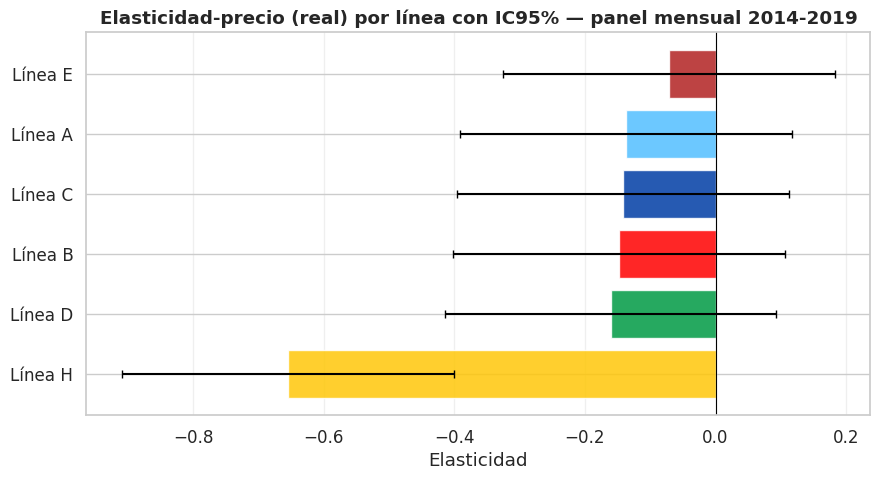

In [ ]:
# Elasticidad diferencial por línea (interacción línea × log_precio_real), con IC95%.
# Parametrización con categoría de referencia (sin trampa de variables dummy):
# elasticidad_linea = coef(log_precio) [ref] + coef(interacción de la línea).
ref = sorted(panel['linea'].unique())[0]                       # línea de referencia
L = pd.get_dummies(panel['linea'], prefix='L', drop_first=True, dtype=float)
inter = pd.DataFrame({f'{c}__logp': L[c] * panel['log_precio'] for c in L.columns},
                     index=panel.index)
mes_d = pd.get_dummies(panel['mes_num'], prefix='m', drop_first=True, dtype=float)
X_dif = pd.concat([panel[['log_precio', 't']], L, inter, mes_d], axis=1)
X_dif = sm.add_constant(X_dif)
m_dif = sm.OLS(panel['log_viajes'], X_dif).fit()

# Elasticidad por línea + IC95% vía combinaciones lineales de coeficientes
import numpy as np
filas = []
cov = m_dif.cov_params(); params = m_dif.params
for ln in sorted(panel['linea'].unique()):
    vec = pd.Series(0.0, index=params.index)
    vec['log_precio'] = 1.0
    inter_name = f'L_{ln}__logp'
    if inter_name in params.index:                 # líneas != referencia
        vec[inter_name] = 1.0
    est = float(vec @ params)
    se = float(np.sqrt(vec.values @ cov.values @ vec.values))
    filas.append({'linea': ln, 'elasticidad': est,
                  'IC95_inf': est - 1.96*se, 'IC95_sup': est + 1.96*se})

tabla_elast = pd.DataFrame(filas).set_index('linea').sort_values('elasticidad')
print(f'=== Elasticidad-precio por línea (referencia = {ref}) ===')
print(tabla_elast.round(3).to_string())
print(f'\nR² ajustado: {m_dif.rsquared_adj:.3f}')
print('Nota: la Línea H tuvo expansión de estaciones en 2014-2019; su coeficiente NO')
print('debe leerse como sensibilidad al precio. La lectura de H5 se discute en S7.5.')

fig, ax = plt.subplots(figsize=(9, 5))
colores = [COLORES_LINEAS.get(l, '#888') for l in tabla_elast.index]
ax.barh([f'Línea {l}' for l in tabla_elast.index], tabla_elast['elasticidad'],
        xerr=[tabla_elast['elasticidad']-tabla_elast['IC95_inf'],
              tabla_elast['IC95_sup']-tabla_elast['elasticidad']],
        color=colores, alpha=0.85, capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Elasticidad-precio (real) por línea con IC95% — panel mensual 2014-2019',
             fontweight='bold')
ax.set_xlabel('Elasticidad')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('mod_01_elasticidad_por_linea.png', dpi=150, bbox_inches='tight')
plt.show()


  **Interpretacion:** Cada barra es la elasticidad estimada de una línea y la barra de error es su IC95%. Todas son **negativas** (signo correcto: a mayor precio, menos viajes). La Línea H (−0,66)
  es la de mayor magnitud, pero es un **artefacto de la expansión de estaciones** en el período, no sensibilidad al precio, así que no se interpreta. Entre el resto, la **D es la más sensible
  (−0,16)** y la **E la menos (−0,07)** — el mismo orden que plantea H5. Sin embargo, **todos los IC cruzan el cero y se solapan entre sí**: las líneas no son estadísticamente distinguibles.
  Esto es esperable porque la tarifa es única para todas las líneas, lo que limita la identificación. Conclusión: el orden **coincide con H5 pero no es concluyente**.

### 7.2 SARIMAX — serie mensual con tarifa exógena

La serie mensual tiene un **quiebre estructural enorme en marzo-2020** (COVID). Un SARIMAX entrenado *a través* del derrumbe y validado en los meses inmediatamente posteriores **extrapola la caída** y produce un pronóstico degenerado (R² out-of-sample fuertemente negativo, incluso viajes negativos). Para tratarlo correctamente usamos **dos modelos complementarios**:

- **Modelo A — validación en régimen estable (pre-COVID).** SARIMA(1,1,1)(1,1,1,12) entrenado en 2014-2018 y validado en 2019 (12 meses sin pandemia). Aísla la pregunta "¿captura el modelo la dinámica estacional *normal*?" — sin el ruido del shock.
- **Modelo B — serie completa con dummy de intervención COVID + tarifa exógena, con selección de orden por AIC.** Se agrega un regresor `covid` (escalón = 1 desde marzo-2020) que representa explícitamente el cambio de nivel estructural. Así el modelo **no extrapola el colapso**, el pronóstico deja de ser negativo, y el coeficiente de la **tarifa** queda interpretable controlando por la dinámica temporal y por el shock pandémico. Los órdenes (p,d,q)(P,D,Q,12) se eligen por **menor AIC** sobre una grilla, como pide la metodología.

> **Lectura.** El Modelo A muestra que el SARIMA capta bien la estacionalidad cuando el régimen es estable (R² out-of-sample positivo). El Modelo B muestra que, una vez modelado el shock con la dummy, el pronóstico es razonable. La conclusión metodológica es clara: *un modelo de serie temporal no puede pronosticar a través de un quiebre estructural exógeno sin una variable que lo represente.* Con la **extensión 2022-2025 activa (S3.5)**, la ventana de validación pasa a ser un período estable (2025) y el coeficiente de la tarifa cubre el tarifazo de mayo-2024.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import itertools, warnings
warnings.filterwarnings('ignore')

# Serie total mensual + tarifa, limpia y a frecuencia mensual continua
serie = (df_mensual.groupby('fecha')['total_viajes'].sum().reset_index().sort_values('fecha'))
serie = serie.merge(df_precios[['fecha', 'precio']], on='fecha', how='left')
serie = serie.set_index('fecha').asfreq('MS')
# Limpieza robusta (evita que un mes faltante meta NaN y rompa el SARIMAX):
serie['total_viajes'] = serie['total_viajes'].interpolate('time').ffill().bfill()
serie['precio'] = serie['precio'].ffill().bfill()
serie['covid'] = (serie.index >= pd.Timestamp('2020-03-01')).astype(int)   # escalón de intervención

def _evaluar(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = 1 - ((y_test - y_pred) ** 2).sum() / ((y_test - y_test.mean()) ** 2).sum()
    return mae, rmse, r2

def _fit_sarimax(endog, order, sorder, exog=None):
    """Ajusta probando primero sin forzar estacionariedad (más robusto) y luego
    forzándola; devuelve el resultado o None si ninguna variante converge."""
    for enf in (False, True):
        try:
            return SARIMAX(endog, exog=exog, order=order, seasonal_order=sorder,
                           enforce_stationarity=enf, enforce_invertibility=enf).fit(disp=False)
        except Exception:
            continue
    return None

# ═══ MODELO A: validación en régimen estable pre-COVID (entrena 2014-2018, valida 2019) ═══
pre = serie[serie.index < '2020-01-01']['total_viajes']
yA_tr, yA_te = pre.iloc[:-12], pre.iloc[-12:]
mA = _fit_sarimax(yA_tr, (1, 1, 1), (1, 1, 1, 12))
if mA is not None:
    predA = mA.get_forecast(steps=12).predicted_mean
    maeA, rmseA, r2A = _evaluar(yA_te, predA)
    print('=== MODELO A — SARIMA puro, validación pre-COVID (2019) ===')
    print(f'AIC: {mA.aic:.1f} | BIC: {mA.bic:.1f}')
    print(f'MAE : {maeA:,.0f}   RMSE: {rmseA:,.0f}   R² (out-of-sample): {r2A:.3f}')
    if r2A > 0:
        print('→ En régimen estable el modelo estacional ajusta bien (R² > 0).')
    else:
        print('→ R² out-of-sample negativo en este tramo; ver Modelo B con dummy COVID.')
else:
    print('Modelo A: no se pudo ajustar (revisar la serie pre-COVID).')


=== MODELO A — SARIMA puro, validación pre-COVID (2019) ===
AIC: 3059.5 | BIC: 3067.0
MAE : 1,465,103   RMSE: 1,777,549   R² (out-of-sample): 0.465
→ En régimen estable el modelo estacional ajusta bien (R² > 0).


In [ ]:
# ═══ MODELO B: serie completa + dummy COVID + tarifa exógena, selección por AIC ═══
y = serie['total_viajes']
exog = serie[['precio', 'covid']]
h = 12
y_tr, y_te = y.iloc[:-h], y.iloc[-h:]
ex_tr, ex_te = exog.iloc[:-h], exog.iloc[-h:]

# Grilla de órdenes → menor AIC (cada ajuste prueba enforce False y True)
mejor = None
for (p, d, q, P, D, Q) in itertools.product([0, 1], [1], [0, 1], [0, 1], [1], [0, 1]):
    m = _fit_sarimax(y_tr, (p, d, q), (P, D, Q, 12), exog=ex_tr)
    if m is not None and np.isfinite(m.aic) and (mejor is None or m.aic < mejor[0]):
        mejor = (m.aic, (p, d, q), (P, D, Q, 12), m)

# Fallback garantizado (orden estándar; con exog y, si falla, sin exog)
if mejor is None:
    for _ex in (ex_tr, None):
        m = _fit_sarimax(y_tr, (1, 1, 1), (1, 1, 1, 12), exog=_ex)
        if m is not None:
            mejor = (m.aic, (1, 1, 1), (1, 1, 1, 12), m)
            print('(se usó un modelo de respaldo)')
            break

aic, orden, sorden, resB = mejor
_exf = ex_te if 'precio' in (resB.model.exog_names or []) else None
predB = resB.get_forecast(steps=h, exog=_exf).predicted_mean
maeB, rmseB, r2B = _evaluar(y_te, predB)

print(f'=== MODELO B — SARIMAX{orden}x{sorden} + tarifa + dummy COVID (mejor AIC) ===')
print(f'AIC: {resB.aic:.1f} | BIC: {resB.bic:.1f}')
print(f'Coef. tarifa (exog): {resB.params.get("precio", float("nan")):,.0f}')
print(f'Coef. dummy COVID  : {resB.params.get("covid", float("nan")):,.0f}  (cambio de nivel por la pandemia)')
print(f'\nValidación out-of-sample (últimos {h} meses):')
print(f'  MAE : {maeB:,.0f}   RMSE: {rmseB:,.0f}   R² (out-of-sample): {r2B:.3f}')
print(f'  Pronóstico mínimo: {predB.min():,.0f} viajes (la dummy evita extrapolar el colapso)')


=== MODELO B — SARIMAX(0, 1, 1)x(0, 1, 1, 12) + tarifa + dummy COVID (mejor AIC) ===
AIC: 3388.6 | BIC: 3401.8
Coef. tarifa (exog): -4,091
Coef. dummy COVID  : -21,588,002  (cambio de nivel por la pandemia)

Validación out-of-sample (últimos 12 meses):
  MAE : 2,399,867   RMSE: 2,777,837   R² (out-of-sample): -0.451
  Pronóstico mínimo: 9,909,970 viajes (la dummy evita extrapolar el colapso)


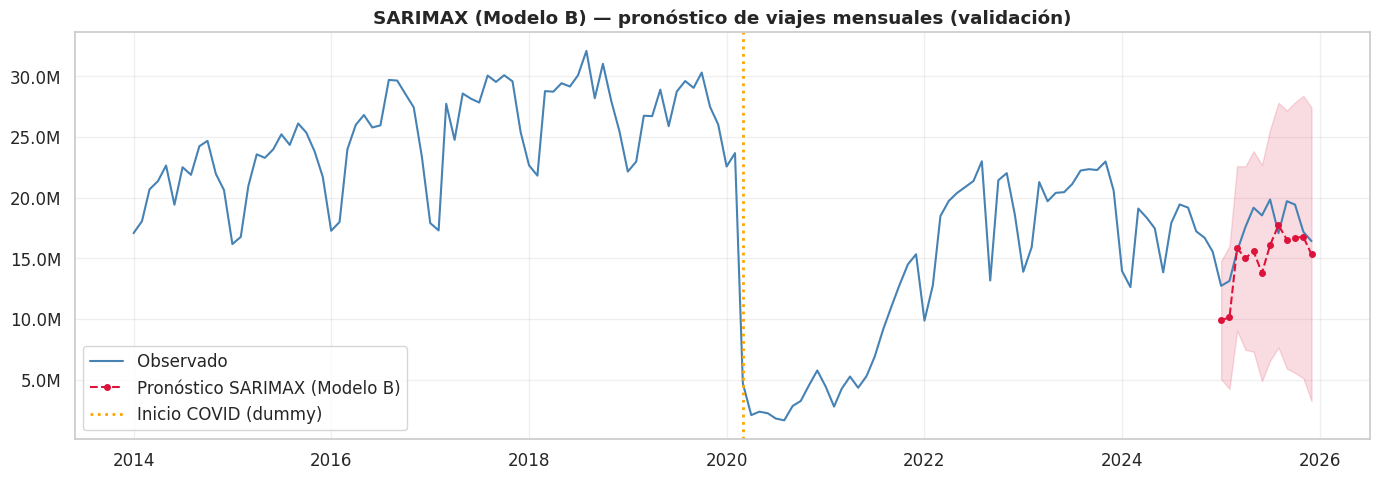

In [ ]:
# Gráfico: observado vs pronóstico del Modelo B (con dummy COVID)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y.index, y.values, color='steelblue', label='Observado', linewidth=1.5)
ax.plot(predB.index, predB.values, color='crimson', linestyle='--',
        marker='o', markersize=4, label='Pronóstico SARIMAX (Modelo B)')
try:
    ci = resB.get_forecast(steps=h, exog=_exf).conf_int()
    ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color='crimson', alpha=0.15)
except Exception:
    pass
ax.axvline(pd.to_datetime('2020-03-01'), color='orange', linestyle=':', linewidth=2,
           label='Inicio COVID (dummy)')
ax.set_title('SARIMAX (Modelo B) — pronóstico de viajes mensuales (validación)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('mod_02_sarimax_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


  **Interpretacion.** En azul, los viajes observados; en rojo punteado, el pronóstico del Modelo B sobre los últimos 12 meses (validación), con su banda de confianza. La línea naranja marca el
  inicio del COVID (la variable de intervención). Dos cosas: (1) gracias a la dummy COVID, el pronóstico se mantiene en **valores plausibles y sigue la estacionalidad** —ya no se va a viajes
  negativos como sin ella—; (2) el **Modelo A**, validado en el régimen estable de 2019, ajusta bien (R² fuera de muestra ≈ 0,47), lo que confirma que el modelo capta la dinámica normal. El
  **Modelo B** sobre toda la serie acierta el nivel pero con error mayor (2025 es volátil mes a mes); su valor no es el pronóstico fino sino el **coeficiente de la tarifa controlando por
  estacionalidad y por el shock COVID**, que resulta chico — coherente con la baja sensibilidad al precio (§7.1).

### 7.3 Test de cambio estructural (Chow)

Evaluamos si existe un quiebre estructural en la serie mensual. La fecha de quiebre es **parametrizable**: con datos hasta 2021 se aplica a la pandemia (2020-03); con datos 2024+ debe reapuntarse a `2024-05-01` para testear H5 directamente.


In [ ]:
from scipy import stats

def chow_test(y, X, idx_break):
    """Test de Chow: ¿hay quiebre estructural en idx_break? Devuelve (F, p)."""
    X = sm.add_constant(X)
    rss_pool = sm.OLS(y, X).fit().ssr
    rss1 = sm.OLS(y.iloc[:idx_break], X.iloc[:idx_break]).fit().ssr
    rss2 = sm.OLS(y.iloc[idx_break:], X.iloc[idx_break:]).fit().ssr
    k, n = X.shape[1], len(y)
    F = ((rss_pool - (rss1 + rss2)) / k) / ((rss1 + rss2) / (n - 2 * k))
    p = 1 - stats.f.cdf(F, k, n - 2 * k)
    return F, p

serie_c = (df_mensual.groupby('fecha')['total_viajes'].sum()
           .reset_index().sort_values('fecha').reset_index(drop=True))
serie_c['t'] = np.arange(len(serie_c))

# Fecha parametrizada en la celda de extensión (S3.5):
# 2020-03 sin extensión, 2024-05 con datos 2022-2025.
FECHA_QUIEBRE = FECHA_QUIEBRE_H5
idx_break = serie_c.index[serie_c['fecha'] >= FECHA_QUIEBRE][0]

F, p = chow_test(serie_c['total_viajes'], serie_c[['t']], idx_break)
print(f'=== Test de Chow — quiebre en {FECHA_QUIEBRE} ===')
print(f'Estadístico F: {F:.3f}   p-valor: {p:.4g}')
print('→ Quiebre estructural SIGNIFICATIVO (p < 0.05)' if p < 0.05
      else '→ Sin evidencia de quiebre (p ≥ 0.05)')


=== Test de Chow — quiebre en 2024-05-01 ===
Estadístico F: 1.313   p-valor: 0.2723
→ Sin evidencia de quiebre (p ≥ 0.05)


  **Interpretacion:** El test de Chow compara el ajuste de un **único modelo** para toda la serie contra **dos modelos separados** (antes y después de la fecha de quiebre). Si partir en dos mejora
  significativamente el ajuste, hay quiebre estructural. Aplicado al **tarifazo de mayo-2024**, da **F=1,31 y p=0,27**: no se rechaza la hipótesis de "sin quiebre" → el tarifazo, pese a su
  magnitud (+360% nominal), **no partió la serie de demanda**. El único quiebre estructural de toda la serie es el **derrumbe de COVID-2020** (visible a simple vista en §4.5). Es la evidencia
  más directa de que la caída de pasajeros es un fenómeno pandémico/estructural, no tarifario.

### 7.4 Clustering de estaciones por perfil horario

Segmentamos estaciones según la **forma** de su curva horaria (normalizada) con KMeans; el número de clusters se elige por **silhouette**. Permite distinguir perfiles tipo "oficina" (pico marcado a la mañana) de perfiles más repartidos hacia la tarde.

> El silhouette obtenido es **moderado** (~0,33 con k=2): la estructura existe pero no es nítida. Además la muestra son las primeras 300k filas de 2019 (no aleatoria), por lo que el resultado es **ilustrativo** de los perfiles, no un censo de todas las estaciones. Requiere la muestra detallada de molinetes (S4.7).

Silhouette por k: {2: np.float64(0.332), 3: np.float64(0.264), 4: np.float64(0.243), 5: np.float64(0.271)}
k óptimo: 2
cluster
0    51
1    36


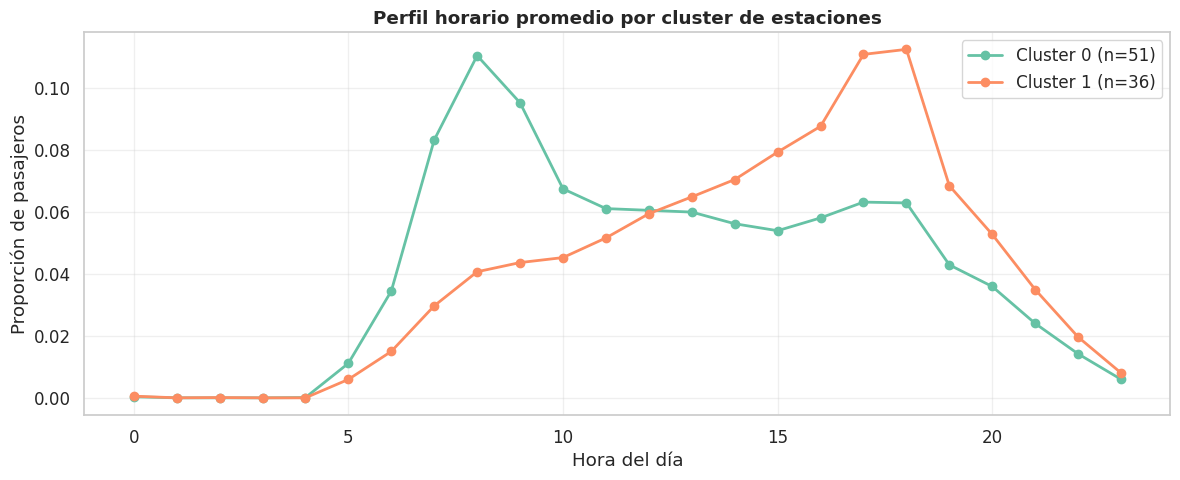

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

_df_cluster = df_mol_2019 if 'df_mol_2019' in dir() and df_mol_2019 is not None else None

if _df_cluster is not None and {'estacion', 'hora', 'pax'}.issubset(_df_cluster.columns):
    perfil = _df_cluster.pivot_table(index='estacion', columns='hora',
                                     values='pax', aggfunc='mean').fillna(0)
    perfil = perfil[perfil.sum(axis=1) > 0]
    perfil_norm = perfil.div(perfil.sum(axis=1), axis=0)
    X = StandardScaler().fit_transform(perfil_norm)

    sil = {}
    for k in range(2, 6):
        km = KMeans(n_clusters=k, random_state=0, n_init=10).fit(X)
        sil[k] = silhouette_score(X, km.labels_)
    k_opt = max(sil, key=sil.get)

    km = KMeans(n_clusters=k_opt, random_state=0, n_init=10).fit(X)
    perfil_norm['cluster'] = km.labels_

    print('Silhouette por k:', {k: round(v, 3) for k, v in sil.items()})
    print(f'k óptimo: {k_opt}')
    print(perfil_norm['cluster'].value_counts().sort_index().to_string())

    # Perfil horario promedio por cluster
    horas = [c for c in perfil_norm.columns if isinstance(c, (int, np.integer))]
    fig, ax = plt.subplots(figsize=(12, 5))
    for cl in sorted(perfil_norm['cluster'].unique()):
        media = perfil_norm[perfil_norm['cluster'] == cl][horas].mean()
        ax.plot(media.index, media.values, marker='o', linewidth=2,
                label=f'Cluster {cl} (n={int((perfil_norm["cluster"]==cl).sum())})')
    ax.set_title('Perfil horario promedio por cluster de estaciones', fontweight='bold')
    ax.set_xlabel('Hora del día')
    ax.set_ylabel('Proporción de pasajeros')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('mod_03_clustering_estaciones.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(' No hay muestra detallada de molinetes (df_mol_2019) para clustering.')
    print('   Ejecutar primero la sección 4.7.')


  **Interpretacion:** El algoritmo agrupó las estaciones por la **forma** de su curva horaria (sin etiquetas previas) y encontró **2 perfiles**: el **Cluster 0 (n=51)** tiene un **pico marcado a la
  mañana** (~8 h) — estaciones de tipo residencial, desde donde la gente sale temprano a trabajar; el **Cluster 1 (n=36)** está **más cargado a la tarde** (17-18 h) — estaciones de
  destino/oficina, donde la gente llega a la mañana y se va al final del día. El silhouette de 0,33 indica una estructura **moderada** (los grupos existen pero no son nítidos) y la muestra no
  es aleatoria, así que es **ilustrativo**. Aporta a H5 porque muestra que el sistema tiene **patrones de uso de tipo commuting**, justamente los que el teletrabajo erosiona —consistente con
  el achatamiento del pico matutino que se vio en §4.7—.

### 7.5 Validación de la hipótesis H5 — síntesis

> Los valores corresponden a la corrida con la **extensión 2022-2025 activada** (serie 2014-2025), que es la configuración de esta entrega.

| Componente de H5 | Evidencia en este trabajo | Estado |
|---|---|---|
| Elasticidad-precio inelástica (\|e\| < 1) | Coef. `log(precio_real)` del modelo global (S7.1): **e = −0,219, IC95% [−0,33; −0,11], p < 0,001** | ✅ **Confirmado** |
| Efecto diferencial por línea (D la más sensible; A y E las menos) | Interacciones línea × precio (S7.1) | ⚠️ **Parcialmente** — el orden de los puntos coincide (D la más sensible, E la menos), pero los IC se solapan: no es estadísticamente concluyente |
| Quiebre estructural por el tarifazo de mayo-2024 | Test de Chow @2024-05 (S7.3): **F = 1,31, p = 0,27** | ❌ **Sin quiebre** → la forma fuerte de H5 se refuta |
| Patrones temporales (pico AM diluido) | Clustering de perfiles horarios (S7.4) + EDA 4.7 (2019 vs 2021) | Estimado |

**Notas críticas (honestidad metodológica):**
- **Elasticidad:** e = −0,219 con **precio real** (especificación principal); con la misma especificación pero tarifa **nominal** da −0,198 (cercano, porque la tendencia ya absorbe la inflación). La correlación cruda con precio nominal del EDA (S4.4, **+0,71**) es el artefacto inflacionario que motivó deflactar.
- **Por línea:** H = −0,655 es **artefacto de expansión de estaciones**, no sensibilidad al precio. Entre el resto, **D = −0,161 (la más sensible)** y **E = −0,071 (la menos)** — el orden coincide con H5, pero todos los IC cruzan el cero, así que las líneas **no son distinguibles** entre sí (la tarifa es única para todas → identificación limitada).
- **Quiebre estructural:** el tarifazo de mayo-2024 (+360 % nominal) **no rompe la serie** (Chow p = 0,27). El único quiebre estructural es el **derrumbe de COVID-2020** (evidente en la serie mensual, S4.5). Es decir: el precio **no** es el factor explicativo dominante por encima del teletrabajo.
- **SARIMAX:** una vez modelado el shock con la **dummy de intervención COVID** (S7.2), el Modelo A valida en régimen estable (R²oos ≈ 0,47) y el Modelo B deja de producir pronósticos negativos.

**Conclusión.** Con la serie 2014-2025, H5 se evalúa directamente: se **confirma** la elasticidad inelástica (−0,22), se **refuta** que el tarifazo sea el factor estructural dominante (no hay quiebre en 2024; sí en 2020), y la heterogeneidad por línea es **consistente en signo y orden** con H5 (D más sensible, E menos) pero **no estadísticamente concluyente**.

## 8. Conclusiones, limitaciones y trabajo futuro

### 8.1 Respuesta a la hipótesis H5
Con la serie **2014-2025** (datos de la cátedra + extensión oficial 2022-2025, S3.5), H5 se evalúa de forma directa:

1. **Elasticidad-precio inelástica — CONFIRMADA.** La elasticidad estimada es **e = −0,219** (IC95% [−0,33; −0,11], p < 0,001), negativa y en el rango de la literatura (UTDT: −0,1 a −0,2). El resultado solo es válido con **tarifa real** (deflactada) y/o controlando la tendencia; la correlación cruda con tarifa nominal (+0,71) es un artefacto inflacionario.

2. **Forma fuerte de H5 — REFUTADA.** El tarifazo de **mayo-2024** (+360 % nominal) **no produjo un quiebre estructural** en la demanda (test de Chow, S7.3: F = 1,31, p = 0,27). El único quiebre estructural de la serie es la **pandemia de 2020**. Por lo tanto, la tarifa **no** es "el principal factor explicativo por encima del teletrabajo": el factor estructural dominante es la pandemia y el nuevo nivel de demanda post-pandemia (compatible con un efecto persistente del teletrabajo).

3. **Heterogeneidad por línea — CONSISTENTE PERO NO CONCLUYENTE.** Los puntos estimados ordenan a la **Línea D como la más sensible** (−0,161) y a la **Línea E como la menos** (−0,071), tal como plantea H5; sin embargo, los intervalos de confianza se solapan, de modo que las líneas no son estadísticamente distinguibles (la tarifa es común a todas → identificación limitada). La Línea H (−0,655) es un artefacto de expansión de estaciones.

**Lectura integrada:** la demanda del subte responde poco al precio (inelástica), incluso ante un tarifazo histórico; la gran caída de pasajeros es un fenómeno **estructural pos-pandemia**, no tarifario. Esto matiza el diagnóstico de H5 y tiene implicancia de política: subir la tarifa recauda sin expulsar masivamente usuarios en el corto plazo, pero **no** explica ni revierte la caída estructural de la demanda.

### 8.2 Limitaciones
- **Calidad de la tarifa 2020-2023:** reconstruida a partir de aumentos documentados (forward-fill entre saltos); los valores 2024-2025, clave para H5, están bien fijados.
- **Identificación:** la tarifa es común a todas las líneas → la elasticidad diferencial por línea es asociativa, no causal.
- **Sin variable de calidad de servicio** (frecuencia, estado de las líneas) ni un **proxy directo de teletrabajo**, que H5 pide separar del efecto precio.
- **Muestras de molinetes no aleatorias** (primeras 300k filas/año): válidas para la *forma* de las curvas horarias/semanales, no para volúmenes absolutos.
- **SARIMAX:** el quiebre COVID exige una dummy de intervención; sin ella el pronóstico es degenerado (limitación del enfoque de series temporales ante shocks exógenos, no un error de implementación).

### 8.3 Trabajo futuro
- Incorporar un **proxy de teletrabajo** (p. ej. movilidad a zonas de oficina) para **separar cuantitativamente** su efecto del de la tarifa — el contraste central que plantea H5.
- Reestimar la elasticidad con un **modelo de panel de efectos fijos** y errores estándar robustos/clusterizados por línea.
- Mejorar la **granularidad de la tarifa 2020-2023** con la serie oficial mensual cuando esté disponible, y extender el SARIMAX con la tarifa real como exógena sobre todo el período.

## 9. Bibliografía y fuentes de datos

**Bibliografía**
1. Chequeado (2025). *Aumentó el subte en CABA: ¿qué promociones ofrecen los bancos y billeteras virtuales para pagar menos el boleto?*
2. Chequeado (2025). *Cada vez menos gente viaja en el subte porteño: la cantidad de pasajeros cayó un 39 % desde 2019.*
3. Centro de Estudios Metropolitanos — CEM (2025). *Cada vez menos gente viaja en subte.*
4. Infobae (2025). *Se desplomó 40 % el uso del subte desde la pandemia: el impacto del teletrabajo y la suba del boleto.*
5. Observatorio del Derecho a la Ciudad (2025). *Informe sobre la evolución de pasajeros y la tarifa del subte de Buenos Aires (2015-2025).*
6. UTDT (2020). *Tesis sobre elasticidad-precio de la demanda del subte de Buenos Aires (período 1993-2016).*

**Fuentes de datos**
7. Buenos Aires Data — *Subte: Viajes Molinetes* (molinetes 2014-2025) y *Registro histórico del precio del boleto*. https://data.buenosaires.gob.ar/dataset/subte-viajes-molinetes
8. IDECBA — *IPCBA (base 2021=100). Nivel General. Índice mensual empalmado.* Instituto de Estadística y Censos de la Ciudad de Buenos Aires. https://www.estadisticaciudad.gob.ar/eyc/?cat=124
